# Rope Flow — Full Pipeline V08

**Course:** MECH 798M / EECE 798K — Data-Driven Modeling  
**Base:** V07 (Topology Features + Cycle-Matrix PCA + Min-Cycle Filter)  

In [29]:
import os, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
from scipy.linalg import svd
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ── Paths ────────────────────────────────────────────────────
DATA_PROCESSED = os.path.join('..', '..', 'data', 'processed')

CONFIG = {
    'FS': 50.0,
    'CYCLE_PROMINENCE_DEGS': 100.0,
    'CYCLE_MIN_PERIOD_S': 0.5,
    'CYCLE_MAX_PERIOD_S': 3.0,
    'TARGET_LEN': 64,
    'N_FOURIER_HARMONICS': 5,
    'PCA_COMPONENTS': 6,
    'TEMPLATE_CORR_THRESHOLD': 0.60,
    'OCSVM_NU': 0.1,
    'OCSVM_GAMMA': 'scale',
    'MIN_CYCLE_SAMPLES': 10,
    'CONFIDENCE_THRESHOLD': 0.7,      # GBM confidence gate for transition rejection
    'TEMPLATE_GATE_THRESHOLD': 0.2,   # min template corr to accept a cycle
}

MACRO_MAP = {
    'underhand': 'foundational', 'overhand': 'foundational',
    'dragon_roll': 'advanced',
    'sneak_underhand': 'sneak', 'sneak_overhand': 'sneak',
    'race_and_chase': 'advanced', 'cheetahs_tail': 'advanced',
}

KNOWN_PATTERNS = set(MACRO_MAP.keys())

PAL = {
    'overhand': '#7F77DD', 'underhand': '#5DCAA5', 'dragon_roll': '#E24B4A',
    'sneak_overhand': '#D85A30', 'sneak_underhand': '#EF9F27',
    'race_and_chase': '#3498db', 'cheetahs_tail': '#e74c3c',
    'transition': '#CCCCCC', 'unknown': '#888888',
}

plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})


# ── Results directory (new folder per run) ───────────────────
import datetime
RUN_NAME = datetime.datetime.now().strftime('run_%Y%m%d_%H%M%S')
RESULTS_DIR = os.path.join('..', '..', 'results', 'Full_pipeline', RUN_NAME)
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f'Results will be saved to: {RESULTS_DIR}')


Results will be saved to: ..\..\results\Full_pipeline\run_20260420_093741


---
## 2. Core pipeline functions 

In [30]:
def load_session(path_d0, path_d1):
    d0 = pd.read_csv(path_d0)
    d1 = pd.read_csv(path_d1)
    return d0, d1

def extract_signals(df):
    t = df['timestamp_ms'].values / 1000.0
    A = df[['ax_w', 'ay_w', 'az_w']].values
    omega = df[['gx', 'gy', 'gz']].values * (np.pi / 180.0)
    Q = df[['qw', 'qx', 'qy', 'qz']].values
    return t, Q, A, omega

# ══════════════════════════════════════════════════════════════
# 2. Cycle detection
# ══════════════════════════════════════════════════════════════
def detect_cycles(t, omega, fs=50.0):
    mag = np.linalg.norm(omega, axis=1)
    mag_smooth = savgol_filter(mag, window_length=15, polyorder=3)
    prom_rads = CONFIG['CYCLE_PROMINENCE_DEGS'] * np.pi / 180.0
    min_dist = int(CONFIG['CYCLE_MIN_PERIOD_S'] * fs)
    peaks, _ = find_peaks(mag_smooth, distance=min_dist, prominence=prom_rads)
    if len(peaks) < 2:
        return [], mag_smooth, peaks
    bounds = ([0]
              + [(peaks[i] + peaks[i+1]) // 2 for i in range(len(peaks) - 1)]
              + [len(t) - 1])
    cycles = [(bounds[i], bounds[i+1]) for i in range(len(bounds) - 1)]
    valid = []
    for s, e in cycles:
        dur = t[e] - t[s]
        if (dur >= CONFIG['CYCLE_MIN_PERIOD_S'] and
            dur <= CONFIG['CYCLE_MAX_PERIOD_S'] and
            (e - s) >= CONFIG['MIN_CYCLE_SAMPLES']):
            valid.append((s, e))
    return valid, mag_smooth, peaks

def pair_cycles(t0, cyc0, t1, cyc1):
    def overlap(s0, e0, s1, e1):
        return max(0.0, min(t0[e0], t1[e1]) - max(t0[s0], t1[s1]))
    paired0, paired1, used = [], [], set()
    for c0 in cyc0:
        best_idx, best_ov = -1, -1.0
        for i, c1 in enumerate(cyc1):
            if i in used:
                continue
            ov = overlap(c0[0], c0[1], c1[0], c1[1])
            if ov > best_ov:
                best_ov, best_idx = ov, i
        if best_idx >= 0 and best_ov > 0:
            paired0.append(c0)
            paired1.append(cyc1[best_idx])
            used.add(best_idx)
    return paired0, paired1

# ══════════════════════════════════════════════════════════════
# 3. Fourier decomposition
# ══════════════════════════════════════════════════════════════
def fourier_features(signal_segment, fs, n_harmonics=5):
    N = len(signal_segment)
    if N < 8:
        return np.zeros(3 + n_harmonics)
    sig = signal_segment - np.mean(signal_segment)
    F = np.abs(np.fft.rfft(sig))
    freqs = np.fft.rfftfreq(N, 1.0 / fs)
    F[0] = 0
    power = F ** 2
    total_power = np.sum(power) + 1e-12
    dom_idx = np.argmax(F[1:]) + 1
    dom_freq = freqs[dom_idx]
    spectral_centroid = np.sum(freqs * power) / total_power
    f0 = dom_freq
    harmonic_ratios = np.zeros(n_harmonics)
    for h in range(n_harmonics):
        target_freq = f0 * (h + 1)
        if target_freq > freqs[-1]:
            break
        idx = np.argmin(np.abs(freqs - target_freq))
        lo = max(1, idx - 1)
        hi = min(len(F), idx + 2)
        harmonic_ratios[h] = np.sum(power[lo:hi]) / total_power
    p_norm = power[1:] / (np.sum(power[1:]) + 1e-12)
    p_norm = p_norm[p_norm > 0]
    spectral_entropy = -np.sum(p_norm * np.log2(p_norm + 1e-12))
    return np.concatenate([[dom_freq, spectral_centroid, spectral_entropy],
                           harmonic_ratios])

def cycle_fourier_features(A, omega, s, e, fs):
    nh = CONFIG['N_FOURIER_HARMONICS']
    feats = []
    omega_mag = np.linalg.norm(omega[s:e], axis=1)
    feats.append(fourier_features(omega_mag, fs, nh))
    acc_mag = np.linalg.norm(A[s:e], axis=1)
    feats.append(fourier_features(acc_mag, fs, nh))
    return np.concatenate(feats)

FOURIER_DIM = 2 * (3 + CONFIG['N_FOURIER_HARMONICS'])
FOURIER_NAMES = []
for ch in ['omega_mag', 'acc_mag']:
    FOURIER_NAMES += [f'{ch}_dom_freq', f'{ch}_spec_centroid', f'{ch}_spec_entropy']
    FOURIER_NAMES += [f'{ch}_harm_{i}' for i in range(CONFIG['N_FOURIER_HARMONICS'])]

# ══════════════════════════════════════════════════════════════
# 4. Physics-grounded features
# ══════════════════════════════════════════════════════════════
def physics_features(t0, t1, A0, A1, om0, om1, s0, e0, s1, e1, fs):
    tc0, tc1 = t0[s0:e0], t1[s1:e1]
    a0, a1 = A0[s0:e0], A1[s1:e1]
    w0, w1 = om0[s0:e0], om1[s1:e1]
    period = tc0[-1] - tc0[0]
    m0 = np.linalg.norm(w0, axis=1)
    m1 = np.linalg.norm(w1, axis=1)
    peak_omega = max(np.max(m0), np.max(m1))
    mean_omega_d0 = np.mean(m0)
    mean_omega_d1 = np.mean(m1)
    acc_rms_d0 = np.sqrt(np.mean(np.sum(a0**2, axis=1)))
    acc_rms_d1 = np.sqrt(np.mean(np.sum(a1**2, axis=1)))
    acc_asym = acc_rms_d0 / (acc_rms_d1 + 1e-8)
    omega_ratio = np.std(m0) / (np.std(m1) + 1e-8)
    n_min = min(len(m0), len(m1))
    if n_min > 4:
        c0 = m0[:n_min] - m0[:n_min].mean()
        c1 = m1[:n_min] - m1[:n_min].mean()
        corr = np.correlate(c0, c1, mode='full')
        lag_samples = np.argmax(corr) - (n_min - 1)
        phase_lag = lag_samples / fs * 1000
    else:
        phase_lag = 0.0
    if len(a0) > 2:
        jerk = np.diff(a0, axis=0) * fs
        jerk_rms = np.sqrt(np.mean(np.sum(jerk**2, axis=1)))
    else:
        jerk_rms = 0.0
    e_rot = np.mean(m0**2) + np.mean(m1**2)
    e_lin = np.mean(np.sum(a0**2, axis=1)) + np.mean(np.sum(a1**2, axis=1))
    ke_ratio = e_rot / (e_rot + e_lin + 1e-8)
    if len(m0) > 10:
        m0c = m0 - m0.mean()
        ac = np.correlate(m0c, m0c, mode='full')
        ac = ac[len(m0c)-1:]
        ac /= (ac[0] + 1e-12)
        min_lag = max(2, int(0.3 * fs))
        peaks_ac, props = find_peaks(ac[min_lag:], height=0)
        periodicity = props['peak_heights'][0] if len(peaks_ac) > 0 else 0.0
    else:
        periodicity = 0.0
    return np.array([
        period, peak_omega, mean_omega_d0, mean_omega_d1,
        acc_rms_d0, acc_rms_d1, acc_asym, omega_ratio,
        phase_lag, jerk_rms, ke_ratio, periodicity
    ])

PHYSICS_NAMES = [
    'period_s', 'peak_omega', 'mean_omega_d0', 'mean_omega_d1',
    'acc_rms_d0', 'acc_rms_d1', 'acc_asymmetry', 'omega_std_ratio',
    'phase_lag_ms', 'jerk_rms', 'ke_ratio', 'periodicity_score'
]

# ══════════════════════════════════════════════════════════════
# 5. SVD features
# ══════════════════════════════════════════════════════════════
def resample_cycle(signal, target_len):
    n = len(signal)
    if n < 2:
        return np.zeros(target_len) if signal.ndim == 1 else np.zeros((target_len, signal.shape[1]))
    x_old = np.linspace(0, 1, n)
    x_new = np.linspace(0, 1, target_len)
    if signal.ndim == 1:
        return np.interp(x_new, x_old, signal)
    else:
        return np.column_stack([np.interp(x_new, x_old, signal[:, j])
                                for j in range(signal.shape[1])])

def build_cycle_matrix(A0, A1, om0, om1, s0, e0, s1, e1, target_len=64):
    state0 = np.column_stack([A0[s0:e0], om0[s0:e0]])
    state1 = np.column_stack([A1[s1:e1], om1[s1:e1]])
    r0 = resample_cycle(state0, target_len)
    r1 = resample_cycle(state1, target_len)
    return np.column_stack([r0, r1]).T  # (12, target_len)

def compute_svd_features(cycle_matrix, n_components=6):
    U, S, Vt = svd(cycle_matrix, full_matrices=False)
    S_ratio = S[:n_components] / (S[0] + 1e-12)
    eff_rank = np.sum(S > 0.01 * S[0])
    total_energy = np.sum(S**2)
    return np.concatenate([S_ratio, [eff_rank, total_energy]])

SVD_DIM = CONFIG['PCA_COMPONENTS'] + 2
SVD_NAMES = ([f'sv_ratio_{i}' for i in range(CONFIG['PCA_COMPONENTS'])]
             + ['eff_rank', 'total_energy'])

# ══════════════════════════════════════════════════════════════
# 6. Template correlation
# ══════════════════════════════════════════════════════════════
def phase_align(cycle_matrix, reference, ref_channel=3):
    """
    Circularly shift cycle_matrix to maximize correlation with reference
    on a chosen channel (default: ωx of D0, row 3).
    This removes arbitrary phase offset from cycle segmentation.
    """
    x = cycle_matrix[ref_channel]
    y = reference[ref_channel]
    x_c = x - np.mean(x)
    y_c = y - np.mean(y)
    corr = np.correlate(np.tile(x_c, 2), y_c, mode='valid')
    shift = np.argmax(corr)
    if shift >= len(x):
        shift -= len(x)
    aligned = np.roll(cycle_matrix, -shift, axis=1)
    return aligned, shift


def build_template(all_cycle_matrices):
    """
    Build overhand template via iterative phase alignment.
    1. Initial template = median-energy cycle
    2. Phase-align all cycles to it
    3. Average the IQR-filtered aligned cycles
    """
    energies = np.array([np.sum(m**2) for m in all_cycle_matrices])
    # Start from the cycle closest to median energy
    median_idx = np.argmin(np.abs(energies - np.median(energies)))
    template = all_cycle_matrices[median_idx].copy()

    # Iterative refinement (2 passes)
    for iteration in range(2):
        aligned = []
        for cm in all_cycle_matrices:
            cm_a, _ = phase_align(cm, template)
            aligned.append(cm_a)
        # IQR filter on energy
        q25, q75 = np.percentile(energies, [25, 75])
        mask = (energies >= q25) & (energies <= q75)
        selected = [a for a, keep in zip(aligned, mask) if keep]
        if len(selected) < 3:
            selected = aligned
        template = np.mean(selected, axis=0)

    return template


def template_correlation(cycle_matrix, template):
    """
    Phase-aligned normalized correlation between cycle and template.
    Returns mean and min correlation across all 12 channels.
    """
    aligned, _ = phase_align(cycle_matrix, template)
    n_channels = aligned.shape[0]
    corrs = np.zeros(n_channels)
    for ch in range(n_channels):
        x = aligned[ch] - np.mean(aligned[ch])
        y = template[ch] - np.mean(template[ch])
        denom = (np.linalg.norm(x) * np.linalg.norm(y) + 1e-12)
        corrs[ch] = np.dot(x, y) / denom
    return np.mean(corrs), np.min(corrs)

TEMPLATE_NAMES = ['template_corr_mean', 'template_corr_min']

# ══════════════════════════════════════════════════════════════
# 7. DMD eigenvalue features — dynamical fingerprint
# ══════════════════════════════════════════════════════════════
def dmd_features(cycle_matrix, dt):
    """
    DMD eigenvalue features — subject-invariant dynamical fingerprint.
    Captures the linear operator governing one cycle's dynamics.
    Returns top-3 frequencies, top-3 growth rates, rank, mean/max stability.
    """
    X1, X2 = cycle_matrix[:, :-1], cycle_matrix[:, 1:]
    U, S, Vh = svd(X1, full_matrices=False)
    cumvar = np.cumsum(S**2) / (np.sum(S**2) + 1e-12)
    r = min(int(np.searchsorted(cumvar, 0.99)) + 1, len(S), X1.shape[1])
    r = max(r, 1)
    A_t = U[:,:r].T @ X2 @ Vh[:r,:].T @ np.diag(1.0 / (S[:r] + 1e-12))
    lam_d, _ = np.linalg.eig(A_t)
    lam_c = np.log(np.maximum(np.abs(lam_d), 1e-12)) / dt
    freqs = np.abs(lam_c.imag) / (2 * np.pi)
    growth = lam_c.real
    order = np.argsort(freqs)[::-1]
    freqs, growth = freqs[order], growth[order]
    n_top = 3
    f_top, g_top = np.zeros(n_top), np.zeros(n_top)
    for i in range(min(n_top, len(freqs))):
        f_top[i] = freqs[i]; g_top[i] = growth[i]
    return np.concatenate([f_top, g_top, [r, np.mean(growth), np.max(np.abs(growth))]])

DMD_FEAT_NAMES = ([f'dmd_freq_{i}' for i in range(3)]
                  + [f'dmd_growth_{i}' for i in range(3)]
                  + ['dmd_rank', 'dmd_mean_growth', 'dmd_max_abs_growth'])


# ══════════════════════════════════════════════════════════════
# 8. Subject-invariant features — ratios that cancel person effects
# ══════════════════════════════════════════════════════════════
def subject_invariant_features(t0, t1, A0, A1, om0, om1, s0, e0, s1, e1, fs):
    """
    Features designed to be invariant to subject-specific scaling.
    Uses D1/D0 ratios, statistical shape (skewness, kurtosis),
    and inter-hand correlation — all dimensionless.
    """
    from scipy.stats import skew, kurtosis as kurt
    a0, a1 = A0[s0:e0], A1[s1:e1]
    w0, w1 = om0[s0:e0], om1[s1:e1]
    m0 = np.linalg.norm(w0, axis=1)
    m1 = np.linalg.norm(w1, axis=1)
    am0 = np.linalg.norm(a0, axis=1)
    am1 = np.linalg.norm(a1, axis=1)
    n = min(len(m0), len(m1))
    return np.array([
        np.mean(m1) / (np.mean(m0) + 1e-8),       # ω ratio D1/D0
        np.mean(am1) / (np.mean(am0) + 1e-8),      # acc ratio D1/D0
        np.std(m1) / (np.std(m0) + 1e-8),           # ω variability ratio
        np.max(m1) / (np.max(m0) + 1e-8),           # peak ω ratio
        skew(m0), skew(m1),                          # temporal shape
        kurt(m0), kurt(m1),
        np.corrcoef(m0[:n], m1[:n])[0, 1] if n > 4 else 0.0,  # inter-hand coupling
    ])

SI_FEAT_NAMES = ['omega_ratio_d1d0', 'acc_ratio_d1d0', 'omega_std_ratio_si',
                 'peak_omega_ratio', 'skew_omega_d0', 'skew_omega_d1',
                 'kurt_omega_d0', 'kurt_omega_d1', 'phase_coupling']


# ══════════════════════════════════════════════════════════════
# 9. Full feature extraction
# ══════════════════════════════════════════════════════════════
ALL_FEAT_NAMES = (PHYSICS_NAMES + FOURIER_NAMES + SVD_NAMES + TEMPLATE_NAMES
                  + DMD_FEAT_NAMES + SI_FEAT_NAMES)
N_FEAT = len(ALL_FEAT_NAMES)

def extract_all_features(t0, t1, A0, A1, om0, om1,
                         paired0, paired1, template, fs):
    features = []
    dt = 1.0 / fs
    for (s0, e0), (s1, e1) in zip(paired0, paired1):
        phys = physics_features(t0, t1, A0, A1, om0, om1, s0, e0, s1, e1, fs)
        fourier = cycle_fourier_features(A0, om0, s0, e0, fs)
        cm = build_cycle_matrix(A0, A1, om0, om1, s0, e0, s1, e1,
                                CONFIG['TARGET_LEN'])
        svd_feat = compute_svd_features(cm, CONFIG['PCA_COMPONENTS'])
        corr_mean, corr_min = template_correlation(cm, template)
        tmpl_feat = np.array([corr_mean, corr_min])
        dmd_feat = dmd_features(cm, dt)
        si_feat = subject_invariant_features(t0, t1, A0, A1, om0, om1,
                                             s0, e0, s1, e1, fs)
        feat = np.concatenate([phys, fourier, svd_feat, tmpl_feat,
                               dmd_feat, si_feat])
        features.append(feat)
    return np.array(features)

# ══════════════════════════════════════════════════════════════
# 10. Multi-session training & cross-validation
# ══════════════════════════════════════════════════════════════
def process_session(path_d0, path_d1):
    """Load and preprocess a single session. Returns signals + cycle info."""
    d0, d1 = load_session(path_d0, path_d1)
    t0, Q0, A0, om0 = extract_signals(d0)
    t1, Q1, A1, om1 = extract_signals(d1)
    fs = CONFIG['FS']
    cyc0, mag0_smooth, peaks0 = detect_cycles(t0, om0, fs)
    cyc1, _, _ = detect_cycles(t1, om1, fs)
    p0, p1 = pair_cycles(t0, cyc0, t1, cyc1)
    cms = [build_cycle_matrix(A0, A1, om0, om1, s0, e0, s1, e1, CONFIG['TARGET_LEN'])
           for (s0, e0), (s1, e1) in zip(p0, p1)]
    return {
        't0': t0, 't1': t1, 'A0': A0, 'A1': A1, 'om0': om0, 'om1': om1,
        'paired0': p0, 'paired1': p1, 'cycle_matrices': cms,
        'mag0_smooth': mag0_smooth, 'peaks0': peaks0,
    }





---
## 3. Functions
Adds heterogeneous session discovery, windowed cycle filtering,
stratified group split, recording-group-aware LOSO, and held-out test evaluation.

In [31]:
# ══════════════════════════════════════════════════════════════════════════
#  FUNCTIONS
# Adds: heterogeneous session discovery, windowed processing,
#       stratified group split, updated train/classify/LOSO/evaluate
# ══════════════════════════════════════════════════════════════════════════
import re as _re, json as _json
from collections import defaultdict

DATA_RAW        = os.path.join('..', '..', 'data', 'raw')
NEW_LABELED_RAW = os.path.join(DATA_RAW, 'new-labeled-sessions')

# ── Label mapping (mirrors 08_Build_labels_index) ──────────────────────
_EXACT_MAP = {
    'underhand':'underhand','overhand':'overhand','dragon_roll':'dragon_roll',
    'sneak_underhand':'sneak_underhand','sneak_overhand':'sneak_overhand',
    'race_and_chase':'race_and_chase','cheetahs_tail':'cheetahs_tail',
    'idle':None,
}
_PREFIX_RULES = [
    (_re.compile(r'^us', _re.I), 'sneak_underhand'),
    (_re.compile(r'^os', _re.I), 'sneak_overhand'),
    (_re.compile(r'^u',  _re.I), 'underhand'),
    (_re.compile(r'^o',  _re.I), 'overhand'),
    (_re.compile(r'^fb', _re.I), 'dragon_roll'),
    (_re.compile(r'^bf', _re.I), 'dragon_roll'),
    (_re.compile(r'^cw$',  _re.I), None),
    (_re.compile(r'^ccw$', _re.I), None),
    (_re.compile(r'^idle', _re.I), None),
    (_re.compile(r'^vq',   _re.I), None),
]
def _map_label(raw):
    raw = raw.strip()
    if raw.lower() in _EXACT_MAP:
        return _EXACT_MAP[raw.lower()]
    for pat, c in _PREFIX_RULES:
        if pat.match(raw):
            return c
    return None


# ── Session discovery ──────────────────────────────────────────────────
def discover_sessions(processed_dir):
    """
    Homogeneous sessions from unified-data.
    Returns list of 5-tuples (d0, d1, label, display_name, time_windows=None).
    """
    csv_files = sorted(glob.glob(os.path.join(processed_dir, '*_device0_processed.csv')))
    sessions = []
    for d0_path in csv_files:
        d1_path = d0_path.replace('_device0_', '_device1_')
        if not os.path.exists(d1_path):
            continue
        stem = os.path.basename(d0_path).replace('_device0_processed.csv', '')
        parts = stem.split('_')
        if len(parts) < 3:
            continue
        remaining = parts[2:]
        label = None
        for n in range(len(remaining), 0, -1):
            if '_'.join(remaining[:n]) in KNOWN_PATTERNS:
                label = '_'.join(remaining[:n])
                subject = '_'.join(remaining[n:]) or 'unknown'
                break
        if label is None:
            continue
        display_name = f'{label}_{subject}'
        sessions.append((d0_path, d1_path, label, display_name, None))
    return sessions


def discover_heterogeneous_sessions(processed_dir, raw_dir=None):
    """
    Per-label entries from new-labeled-sessions JSON files.
    One 5-tuple per (recording, canonical_label) pair.
    display_name = 'session_name/label'  (slash used as LOSO group key separator)
    time_windows = [(start_s, end_s), ...] for that label
    """
    if raw_dir is None:
        raw_dir = NEW_LABELED_RAW
    if not os.path.isdir(raw_dir):
        return []
    entries = []
    for sname in sorted(os.listdir(raw_dir)):
        sdir = os.path.join(raw_dir, sname)
        if not os.path.isdir(sdir):
            continue
        lpath = None
        for fn in ('labels_corrected.json', 'labels.json'):
            p = os.path.join(sdir, fn)
            if os.path.isfile(p):
                lpath = p
                break
        if lpath is None:
            continue
        d0 = os.path.join(processed_dir, f'{sname}_device0_processed.csv')
        d1 = os.path.join(processed_dir, f'{sname}_device1_processed.csv')
        if not (os.path.isfile(d0) and os.path.isfile(d1)):
            continue
        with open(lpath, encoding='utf-8') as fh:
            data = _json.load(fh)
        windows_by_label = defaultdict(list)
        for seg in data.get('segments', []):
            canon = _map_label(seg.get('label', ''))
            if canon is None:
                continue
            s = seg.get('start')
            e = seg.get('end')
            if s is None:
                continue
            if e is None:
                e = s + 2.0
            windows_by_label[canon].append((float(s), float(e)))
        for label, windows in sorted(windows_by_label.items()):
            entries.append((d0, d1, label, f'{sname}/{label}', windows))
    return entries


def discover_all_sessions(processed_dir):
    """Combine homogeneous + heterogeneous entries, excluding sparse classes."""
    EXCLUDE_CLASSES = {'cheetahs_tail', 'race_and_chase'}
    all_entries = discover_sessions(processed_dir) + discover_heterogeneous_sessions(processed_dir)
    filtered = [e for e in all_entries if e[2] not in EXCLUDE_CLASSES]
    excluded = [e for e in all_entries if e[2] in EXCLUDE_CLASSES]
    if excluded:
        print(f'Excluded {len(excluded)} entries from classes: {EXCLUDE_CLASSES}')
    return filtered


def session_group(entry):
    """Recording-level group key — slash in display_name separates session/label."""
    dn = entry[3]
    return dn.split('/')[0] if '/' in dn else dn


def summarize_sessions(sessions):
    by_class = defaultdict(list)
    for e in sessions:
        by_class[e[2]].append(e[3])
    print(f'Discovered {len(sessions)} entries across {len(by_class)} classes:')
    for label in sorted(by_class.keys()):
        names = by_class[label]
        print(f'  {label:<22s}: {len(names):>3d} entries')
        for n in names:
            print(f'    - {n}')
    singletons = [l for l, s in by_class.items() if len(s) == 1]
    if singletons:
        print(f'\nWarning: {len(singletons)} singleton classes: {singletons}')
    return dict(by_class)


# ── Stratified group train/test split ─────────────────────────────────
def stratified_group_split(sessions, test_fraction=0.2, random_state=42, min_train_fraction=0.8):
    """
    Split sessions into train/test, keeping recording groups atomic.
    Stratifies by estimated cycle count (not entry count) to prevent
    inverted splits when heterogeneous groups have many entries.
    Singletons (classes with only 1 group) always stay in train.
    Enforces at least min_train_fraction in train (default: 80%).
    """
    import random as _rand
    rng = _rand.Random(random_state)

    groups = defaultdict(list)
    for e in sessions:
        groups[session_group(e)].append(e)

    # Estimate cycle count per group (use entry count as proxy if no data loaded)
    group_weight = {g: len(entries) for g, entries in groups.items()}

    class_to_groups = defaultdict(list)
    for gname, entries in groups.items():
        for lbl in set(e[2] for e in entries):
            class_to_groups[lbl].append(gname)

    test_groups = set()
    for lbl, gnames in sorted(class_to_groups.items()):
        if len(gnames) < 2:
            continue  # singleton class — keep in train
        # Sort by weight (smallest groups go to test first to avoid overshooting)
        gnames_sorted = sorted(gnames, key=lambda g: group_weight[g])
        rng.shuffle(gnames_sorted)
        # Compute target: test_fraction of total entries for this class
        total_entries = sum(len(groups[g]) for g in gnames)
        target_test = max(1, total_entries * test_fraction)
        if target_test >= total_entries * 0.2:
            target_test = 1  # never put more than 1 group in test per class
        test_count = 0
        for g in gnames_sorted:
            if g in test_groups:
                test_count += len(groups[g])
                continue
            if test_count < target_test:  # strict: stop as soon as target met
                test_groups.add(g)
                test_count += len(groups[g])

    # Enforce minimum train fraction (at least 80% by default)
    total_entries = len(sessions)
    max_test_entries = int(np.floor((1.0 - min_train_fraction) * total_entries))
    current_test_entries = sum(len(groups[g]) for g in test_groups)
    if current_test_entries > max_test_entries:
        # Move smallest test groups back to train until constraint is satisfied
        for g in sorted(list(test_groups), key=lambda k: len(groups[k])):
            if current_test_entries <= max_test_entries:
                break
            test_groups.remove(g)
            current_test_entries -= len(groups[g])

    train = [e for e in sessions if session_group(e) not in test_groups]
    test  = [e for e in sessions if session_group(e) in test_groups]

    return train, test


# ── Windowed session processing ────────────────────────────────────────
def process_session_windowed(path_d0, path_d1, windows):
    """
    Like process_session but only keeps cycles whose midpoint falls inside
    one of the provided (start_s, end_s) windows.
    """
    d0, d1 = load_session(path_d0, path_d1)
    t0, _Q0, A0, om0 = extract_signals(d0)
    t1, _Q1, A1, om1 = extract_signals(d1)
    fs = CONFIG['FS']
    cyc0, mag0_smooth, peaks0 = detect_cycles(t0, om0, fs)
    cyc1, _, _ = detect_cycles(t1, om1, fs)
    p0, p1 = pair_cycles(t0, cyc0, t1, cyc1)

    fp0, fp1 = [], []
    for (s0, e0), (s1, e1) in zip(p0, p1):
        t_mid = (t0[s0] + t0[e0]) / 2.0
        if any(ws <= t_mid < we for ws, we in windows):
            fp0.append((s0, e0))
            fp1.append((s1, e1))

    cms = [build_cycle_matrix(A0, A1, om0, om1, s0, e0, s1, e1, CONFIG['TARGET_LEN'])
           for (s0, e0), (s1, e1) in zip(fp0, fp1)]
    return {
        't0': t0, 't1': t1, 'A0': A0, 'A1': A1, 'om0': om0, 'om1': om1,
        'paired0': fp0, 'paired1': fp1, 'cycle_matrices': cms,
        'mag0_smooth': mag0_smooth, 'peaks0': peaks0,
    }


def _load_entry(entry):
    """Dispatch to process_session or process_session_windowed."""
    d0, d1, label, dname, tw = entry
    return process_session(d0, d1) if tw is None else process_session_windowed(d0, d1, tw)


# ── model training ───────────────────────────────────────────────────────
def train_model_legacy_v1(session_list, verbose=True, gbm_params=None):
    """
    Train multi-class GBM from 5-tuple entries (homogeneous + heterogeneous).
    Global scaling only (no per-entry z-scoring).
    """
    fs = CONFIG['FS']
    all_cms, all_sessions, all_labels = [], [], []

    for entry in session_list:
        d0, d1, label, dname, tw = entry
        sess = _load_entry(entry)
        all_sessions.append(sess)
        all_cms.extend(sess['cycle_matrices'])
        all_labels.append(label)
        if verbose:
            print(f'  {label:<22s} [{dname}]: {len(sess["paired0"])} cycles')

    if not all_cms:
        raise ValueError('No cycles found — check processed data paths.')

    template = build_template(all_cms)

    class_cms = defaultdict(list)
    for sess, lbl in zip(all_sessions, all_labels):
        class_cms[lbl].extend(sess['cycle_matrices'])
    class_templates = {lbl: build_template(cms) for lbl, cms in class_cms.items()}

    X_list, y_list, sid_list = [], [], []
    for si, (sess, lbl) in enumerate(zip(all_sessions, all_labels)):
        X = extract_all_features(
            sess['t0'], sess['t1'], sess['A0'], sess['A1'],
            sess['om0'], sess['om1'], sess['paired0'], sess['paired1'],
            template, fs)
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
        X_list.append(X)
        y_list.extend([lbl] * len(X))
        sid_list.extend([si] * len(X))

    X_all   = np.vstack(X_list)
    y_all   = np.array(y_list)
    sid_all = np.array(sid_list)

    # Global StandardScaler (fitted on training data only, no per-entry z-scoring)
    # Per-entry z-scoring was erasing absolute kinematic magnitudes that
    # discriminate patterns (e.g., dragon_roll has higher total_energy than underhand)
    scaler  = StandardScaler()
    X_s     = scaler.fit_transform(X_all)
    le      = LabelEncoder()
    y_enc   = le.fit_transform(y_all)

    gbm_params = {} if gbm_params is None else dict(gbm_params)
    params = {
        'n_estimators': 300,
        'max_depth': 3,
        'learning_rate': 0.05,
        'random_state': 42,
    }
    params.update(gbm_params)
    clf = GradientBoostingClassifier(**params)
    clf.fit(X_s, y_enc)

    if verbose:
        print(f'\nTrained on {X_all.shape[0]} cycles x {X_all.shape[1]} features')
        print(f'Classes: {list(le.classes_)}')
        print(f'GBM params: {params}')

    return {
        'clf': clf, 'scaler': scaler, 'label_encoder': le,
        'template': template, 'class_templates': class_templates,
        'feature_names': ALL_FEAT_NAMES,
        'X_train': X_all, 'y_train': y_all, 'session_ids': sid_all,
    }


# ──  classifier (windowed) ──────────────────────────────────────────
def classify_session_legacy_v1(path_d0, path_d1, model, time_windows=None, verbose=True,
                          conf_threshold=None, tmpl_threshold=None):
    """
    Classify with confidence + template transition rejection.
    time_windows: list of (start_s, end_s) to restrict cycles (heterogeneous).
    """
    fs   = CONFIG['FS']
    sess = (process_session(path_d0, path_d1) if time_windows is None
            else process_session_windowed(path_d0, path_d1, time_windows))

    if not sess['paired0']:
        return {'labels': [], 'confidences': [], 'X': np.array([]),
                'verdict': 'unknown', 'vote': {}, 'n_transition': 0, 'session': sess}

    X = extract_all_features(
        sess['t0'], sess['t1'], sess['A0'], sess['A1'],
        sess['om0'], sess['om1'], sess['paired0'], sess['paired1'],
        model['template'], fs)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    if X.ndim < 2 or len(X) == 0:
        if verbose:
            print(f'  0 valid cycles — skipping')
        return {'labels': [], 'confidences': [], 'X': np.empty((0, len(model['feature_names']))),
                'verdict': 'unknown', 'vote': {}, 'n_transition': 0, 'session': sess}

    # Use the global StandardScaler fitted on training data (no per-session z-scoring)
    X_s = model['scaler'].transform(X)

    le           = model['label_encoder']
    y_pred_enc   = model['clf'].predict(X_s)
    y_pred_proba = model['clf'].predict_proba(X_s)
    pred_labels  = le.inverse_transform(y_pred_enc)
    confidences  = np.max(y_pred_proba, axis=1)

    conf_thr = CONFIG['CONFIDENCE_THRESHOLD'] if conf_threshold is None else conf_threshold
    tmpl_thr = CONFIG['TEMPLATE_GATE_THRESHOLD'] if tmpl_threshold is None else tmpl_threshold
    conf_gate = confidences >= conf_thr
    tmpl_gate = np.ones(len(X), dtype=bool)

    labels = []
    for i in range(len(X)):
        labels.append(pred_labels[i] if (conf_gate[i] and tmpl_gate[i]) else 'transition')

    non_trans = [l for l in labels if l != 'transition']
    if non_trans:
        vote    = Counter(non_trans)
        verdict = vote.most_common(1)[0][0]
    else:
        vote    = Counter(labels)
        verdict = 'unknown'

    if verbose:
        print(f'  {len(labels)} cycles | ', end='')
        for cls, cnt in sorted(Counter(labels).items()):
            print(f'{cls}={cnt} ', end='')
        print(f'-> {verdict}')

    return {
        'labels': labels, 'confidences': confidences.tolist(), 'X': X,
        'verdict': verdict, 'vote': dict(Counter(non_trans)),
        'n_transition': sum(1 for l in labels if l == 'transition'),
        'session': sess,
    }


# ── LOSO CV (recording-group aware) ──────────────────────────────────
def run_loso(sessions, verbose=True, conf_threshold=None, tmpl_threshold=None, gbm_params=None):
    """
    Leave-one-recording-group-out CV.
    Group key = session_group(entry) so all segments from the same
    physical recording stay on the same side of each fold.
    Singleton groups are always in train.
    """
    group_counts = Counter(session_group(e) for e in sessions)
    class_group_counts = Counter(e[2] for e in sessions
                                 if group_counts[session_group(e)] >= 1)

    # Identify which classes appear in only one group → singleton
    class_to_groups = defaultdict(set)
    for e in sessions:
        class_to_groups[e[2]].add(session_group(e))
    singleton_classes = {c for c, gs in class_to_groups.items() if len(gs) == 1}

    loso_groups = sorted(set(session_group(e) for e in sessions
                             if e[2] not in singleton_classes))

    if verbose and singleton_classes:
        print(f'Singleton classes (train-only): {sorted(singleton_classes)}')
        print(f'LOSO folds: {len(loso_groups)} recording groups')
        print('=' * 80)

    all_y_true, all_y_pred = [], []
    entry_results = []

    for test_grp in loso_groups:
        test_entries  = [e for e in sessions if session_group(e) == test_grp]
        train_entries = [e for e in sessions if session_group(e) != test_grp]

        model = train_model(train_entries, verbose=False, gbm_params=gbm_params)

        for entry in test_entries:
            d0, d1, true_label, dname, tw = entry
            res = classify_session(
                d0, d1, model, time_windows=tw, verbose=False,
                conf_threshold=conf_threshold, tmpl_threshold=tmpl_threshold)
            if not res['labels']:
                continue
            non_trans = [l for l in res['labels'] if l != 'transition']
            all_y_true.extend([true_label] * len(non_trans))
            all_y_pred.extend(non_trans)
            correct = res['verdict'] == true_label
            entry_results.append((dname, true_label, res['verdict'], correct))
            if verbose:
                status = 'CORRECT' if correct else 'WRONG'
                print(f'  {dname:<52s} GT={true_label:<20s} -> {res["verdict"]:<20s} [{status}]')

    n_correct = sum(1 for r in entry_results if r[3])
    n_total   = len(entry_results)
    print(f'\nLOSO entry accuracy: {n_correct}/{n_total} '
          f'({n_correct/n_total*100:.1f}%)' if n_total else '\nNo LOSO results.')

    result = {
        'entry_results': entry_results,
        'n_correct': n_correct, 'n_total': n_total,
        'session_acc': n_correct / n_total if n_total else 0,
    }
    if all_y_true:
        le = LabelEncoder()
        le.fit(sorted(set(all_y_true + all_y_pred)))
        yt, yp = le.transform(all_y_true), le.transform(all_y_pred)
        print(classification_report(yt, yp, target_names=le.classes_, zero_division=0))
        f1 = f1_score(yt, yp, average='macro', zero_division=0)
        result.update({
            'fine_report': classification_report(yt, yp, target_names=le.classes_, zero_division=0),
            'fine_f1_macro': f1,
            'fine_cm': confusion_matrix(yt, yp),
            'fine_classes': le.classes_,
            'all_y_true': all_y_true,
            'all_y_pred': all_y_pred,
        })
        # Macro-class
        mt = [MACRO_MAP.get(l, 'unknown') for l in all_y_true]
        mp = [MACRO_MAP.get(l, 'unknown') for l in all_y_pred]
        le_m = LabelEncoder()
        le_m.fit(sorted(set(mt + mp)))
        result.update({
            'macro_report': classification_report(le_m.transform(mt), le_m.transform(mp),
                                                  target_names=le_m.classes_, zero_division=0),
            'macro_f1_macro': f1_score(le_m.transform(mt), le_m.transform(mp),
                                       average='macro', zero_division=0),
            'macro_cm': confusion_matrix(le_m.transform(mt), le_m.transform(mp)),
            'macro_classes': le_m.classes_,
        })
    return result


# ── Held-out test evaluation ───────────────────────────────────────────
def evaluate_test_set(test_sessions, model, verbose=True, conf_threshold=None, tmpl_threshold=None):
    """
    Evaluate the final model on held-out test entries.
    Returns per-cycle and per-entry classification metrics.
    """
    all_y_true, all_y_pred = [], []
    entry_results = []

    for entry in test_sessions:
        d0, d1, true_label, dname, tw = entry
        res = classify_session(
            d0, d1, model, time_windows=tw, verbose=False,
            conf_threshold=conf_threshold, tmpl_threshold=tmpl_threshold)
        if not res['labels']:
            continue
        non_trans = [l for l in res['labels'] if l != 'transition']
        all_y_true.extend([true_label] * len(non_trans))
        all_y_pred.extend(non_trans)
        correct = res['verdict'] == true_label
        entry_results.append((dname, true_label, res['verdict'], correct))
        if verbose:
            status = 'CORRECT' if correct else 'WRONG'
            print(f'  {dname:<52s} GT={true_label:<20s} -> {res["verdict"]:<20s} [{status}]')

    n_correct = sum(1 for r in entry_results if r[3])
    n_total   = len(entry_results)
    print(f'\nTest entry accuracy: {n_correct}/{n_total} '
          f'({n_correct/n_total*100:.1f}%)' if n_total else '\nNo test entries.')

    result = {
        'entry_results': entry_results,
        'n_correct': n_correct, 'n_total': n_total,
    }
    if all_y_true:
        le = LabelEncoder()
        le.fit(sorted(set(all_y_true + all_y_pred)))
        yt, yp = le.transform(all_y_true), le.transform(all_y_pred)
        print(classification_report(yt, yp, target_names=le.classes_, zero_division=0))
        f1 = f1_score(yt, yp, average='macro', zero_division=0)
        result.update({
            'fine_report': classification_report(yt, yp, target_names=le.classes_, zero_division=0),
            'test_f1_macro': f1,
            'fine_cm': confusion_matrix(yt, yp),
            'fine_classes': le.classes_,
            'all_y_true': all_y_true,
            'all_y_pred': all_y_pred,
        })
    return result


# ── tuning helpers ───────────────────────────────────────────────
def tune_thresholds(sessions, conf_grid, tmpl_grid, gbm_params=None, verbose=True):
    """
    Grid-search confidence + template thresholds using LOSO F1 (macro).
    Returns best thresholds and score.
    """
    best = {'conf_threshold': None, 'tmpl_threshold': None, 'f1': -1.0}
    for conf in conf_grid:
        for tmpl in tmpl_grid:
            res = run_loso(
                sessions, verbose=False,
                conf_threshold=conf, tmpl_threshold=tmpl,
                gbm_params=gbm_params)
            f1 = res.get('fine_f1_macro', 0.0)
            if verbose:
                print(f'  conf={conf:.2f} tmpl={tmpl:.2f} -> F1={f1:.3f}')
            if f1 > best['f1']:
                best = {'conf_threshold': conf, 'tmpl_threshold': tmpl, 'f1': f1}
    if verbose and best['conf_threshold'] is not None:
        print(f'Best thresholds: conf={best["conf_threshold"]:.2f}, '
              f'tmpl={best["tmpl_threshold"]:.2f} (F1={best["f1"]:.3f})')
    return best


def tune_gbm_params(sessions, gbm_grid, conf_threshold=None, tmpl_threshold=None, verbose=True):
    """
    Small grid-search for GBM params using LOSO F1 (macro).
    Returns best parameter set and score.
    """
    best = {'params': None, 'f1': -1.0}
    for params in gbm_grid:
        res = run_loso(
            sessions, verbose=False,
            conf_threshold=conf_threshold, tmpl_threshold=tmpl_threshold,
            gbm_params=params)
        f1 = res.get('fine_f1_macro', 0.0)
        if verbose:
            print(f'  params={params} -> F1={f1:.3f}')
        if f1 > best['f1']:
            best = {'params': params, 'f1': f1}
    if verbose and best['params'] is not None:
        print(f'Best GBM params: {best["params"]} (F1={best["f1"]:.3f})')
    return best



In [32]:
# Patch: robust handling for empty cycle windows in feature extraction/training
def extract_all_features(t0, t1, A0, A1, om0, om1,
                         paired0, paired1, template, fs):
    features = []
    dt = 1.0 / fs
    for (s0, e0), (s1, e1) in zip(paired0, paired1):
        phys = physics_features(t0, t1, A0, A1, om0, om1, s0, e0, s1, e1, fs)
        fourier = cycle_fourier_features(A0, om0, s0, e0, fs)
        cm = build_cycle_matrix(A0, A1, om0, om1, s0, e0, s1, e1,
                                CONFIG['TARGET_LEN'])
        svd_feat = compute_svd_features(cm, CONFIG['PCA_COMPONENTS'])
        corr_mean, corr_min = template_correlation(cm, template)
        tmpl_feat = np.array([corr_mean, corr_min])
        si_feat = subject_invariant_features(t0, t1, A0, A1, om0, om1,
                                             s0, e0, s1, e1, fs)
        feat = np.concatenate([phys, fourier, svd_feat, tmpl_feat,
                               si_feat])
        features.append(feat)

    if len(features) == 0:
        return np.empty((0, N_FEAT))
    return np.vstack(features)


def train_model_legacy_v2(session_list, verbose=True, gbm_params=None):
    """
    Train multi-class GBM from 5-tuple entries (homogeneous + heterogeneous).
    Skips entries that produce zero valid cycles after windowing/filtering.
    """
    fs = CONFIG['FS']
    all_cms, all_sessions, all_labels, all_dnames = [], [], [], []

    for entry in session_list:
        d0, d1, label, dname, tw = entry
        sess = _load_entry(entry)
        all_sessions.append(sess)
        all_cms.extend(sess['cycle_matrices'])
        all_labels.append(label)
        all_dnames.append(dname)
        if verbose:
            print(f'  {label:<22s} [{dname}]: {len(sess["paired0"])} cycles')

    if not all_cms:
        raise ValueError('No cycles found — check processed data paths.')

    template = build_template(all_cms)

    class_cms = defaultdict(list)
    for sess, lbl in zip(all_sessions, all_labels):
        class_cms[lbl].extend(sess['cycle_matrices'])
    class_templates = {lbl: build_template(cms) for lbl, cms in class_cms.items() if len(cms) > 0}

    X_list, y_list, sid_list = [], [], []
    kept = 0
    for si, (sess, lbl, dname) in enumerate(zip(all_sessions, all_labels, all_dnames)):
        X = extract_all_features(
            sess['t0'], sess['t1'], sess['A0'], sess['A1'],
            sess['om0'], sess['om1'], sess['paired0'], sess['paired1'],
            template, fs)
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

        if X.shape[0] == 0:
            if verbose:
                print(f'    Skipping empty entry: {dname} ({lbl})')
            continue

        X_list.append(X)
        y_list.extend([lbl] * len(X))
        sid_list.extend([si] * len(X))
        kept += 1

    if not X_list:
        raise ValueError('All training entries produced zero valid cycles after filtering.')

    X_all   = np.vstack(X_list)
    y_all   = np.array(y_list)
    sid_all = np.array(sid_list)

    scaler  = StandardScaler()
    X_s     = scaler.fit_transform(X_all)
    le      = LabelEncoder()
    y_enc   = le.fit_transform(y_all)

    gbm_params = {} if gbm_params is None else dict(gbm_params)
    params = {
        'n_estimators': 200,
        'max_depth': 3,
        'learning_rate': 0.08,
        'random_state': 42,
    }
    params.update(gbm_params)
    clf = GradientBoostingClassifier(**params)
    clf.fit(X_s, y_enc)

    if verbose:
        print(f'\nTrained on {X_all.shape[0]} cycles x {X_all.shape[1]} features')
        print(f'Classes: {list(le.classes_)}')
        print(f'Entries kept: {kept}/{len(session_list)}')
        print(f'GBM params: {params}')

    return {
        'clf': clf, 'scaler': scaler, 'label_encoder': le,
        'template': template, 'class_templates': class_templates,
        'feature_names': ALL_FEAT_NAMES,
        'X_train': X_all, 'y_train': y_all, 'session_ids': sid_all,
    }

---
## 2b. Topology + shape PCA features

**14D topology features** capture 3D trajectory shape that scalar features miss:
- Cross-axis phase lags normalized by dominant period (T_dom)
- Plane and spatial ratios (σ₂/σ₁ and σ₃/σ₁ from 3-axis gyro SVD)
- Invariant winding (zero-crossings per cycle for ωx and ωy)

**Shape PCA (top-k)** preserves temporal waveform structure:
- Flatten 12×64 cycle matrix to 768D, fit PCA on training data, keep top-k for 96% variance

In [33]:
# ══════════════════════════════════════════════════════════════
# Topology features — capture 3D trajectory shape
# ══════════════════════════════════════════════════════════════
def topology_features(om0, om1, s0, e0, s1, e1, fs):
    """Enhanced topology features with sneak-sensitive dynamic descriptors."""
    feats = []

    def _phase_lag_deg(a, b, t_ref):
        a_c, b_c = a - np.mean(a), b - np.mean(b)
        corr = np.correlate(a_c, b_c, mode='full')
        lag_samples = np.argmax(corr) - (len(a) - 1)
        phase_deg = (lag_samples / max(1.0, t_ref)) * 360.0
        return np.abs((phase_deg + 180.0) % 360.0 - 180.0)

    for w_raw in [om0[s0:e0], om1[s1:e1]]:
        w = w_raw.copy()
        n = len(w)
        if n < 6:
            feats.extend([0.0] * 19)
            continue

        wx, wy, wz = w[:, 0], w[:, 1], w[:, 2]

        # ---------- 1. Dominant period ----------
        w_norm = np.linalg.norm(w, axis=1)
        w_norm_c = w_norm - np.mean(w_norm)
        acorr = np.correlate(w_norm_c, w_norm_c, mode='full')[n-1:]
        min_lag = max(2, int(CONFIG['CYCLE_MIN_PERIOD_S'] * fs))
        max_lag = min(n - 2, int(CONFIG['CYCLE_MAX_PERIOD_S'] * fs))
        if max_lag > min_lag:
            ac_seg = acorr[min_lag:max_lag + 1]
            prom = max(1e-12, 0.05 * acorr[0])
            peaks, props = find_peaks(ac_seg, prominence=prom)
            if len(peaks) > 0:
                best = peaks[np.argmax(props['prominences'])]
                T_dom = float(min_lag + best)
            else:
                T_dom = float(max(1, n))
        else:
            T_dom = float(max(1, n))

        # ---------- 2. Cross-axis phase lags ----------
        phase_xy = _phase_lag_deg(wx, wy, T_dom)
        phase_xz = _phase_lag_deg(wx, wz, T_dom)
        phase_yz = _phase_lag_deg(wy, wz, T_dom)
        feats.extend([phase_xy, phase_xz, phase_yz])

        # ---------- 3. SVD spatial ratios ----------
        _, S_w, _ = np.linalg.svd(w.T, full_matrices=False)
        if len(S_w) >= 3:
            s_sum = S_w[0] + 1e-12
            feats.append(S_w[1] / s_sum)  # planarity
            feats.append(S_w[2] / s_sum)  # spatial complexity
        else:
            feats.extend([0.0, 0.0])

        # ---------- 4. Winding numbers ----------
        cycles = max(1.0, n / T_dom)
        wx_zc = np.sum(np.diff(np.sign(wx - np.mean(wx))) != 0)
        wy_zc = np.sum(np.diff(np.sign(wy - np.mean(wy))) != 0)
        feats.extend([wx_zc / cycles, wy_zc / cycles])

        # ---------- 5. Axis energy distribution ----------
        energy = np.array([np.mean(wx**2), np.mean(wy**2), np.mean(wz**2)])
        energy /= (np.sum(energy) + 1e-12)
        feats.extend(energy.tolist())

        # ---------- 6. Torsion + variability ----------
        v_shift = np.roll(w, -1, axis=0)
        cross_mag = np.linalg.norm(np.cross(w[:-1], v_shift[:-1]), axis=1)
        torsion = float(np.mean(cross_mag)) if len(cross_mag) else 0.0
        torsion_var = float(np.var(cross_mag)) if len(cross_mag) > 1 else 0.0
        feats.extend([torsion, torsion_var])

        # ---------- 7. Temporal variability ----------
        temporal_var = float(np.var(w_norm))

        # Phase variability in short windows (sneak sensitivity)
        phase_win = max(6, int(0.5 * T_dom))
        phase_step = max(1, phase_win // 2)
        phase_xy_vals, phase_yz_vals = [], []
        if phase_win < n:
            for st in range(0, n - phase_win + 1, phase_step):
                swx = wx[st:st + phase_win]
                swy = wy[st:st + phase_win]
                swz = wz[st:st + phase_win]
                phase_xy_vals.append(_phase_lag_deg(swx, swy, T_dom))
                phase_yz_vals.append(_phase_lag_deg(swy, swz, T_dom))
        phase_xy_var = float(np.var(phase_xy_vals)) if len(phase_xy_vals) > 1 else 0.0
        phase_yz_var = float(np.var(phase_yz_vals)) if len(phase_yz_vals) > 1 else 0.0

        # Local nonstationarity: variance of short-window temporal variance
        local_win = max(6, int(0.25 * T_dom))
        local_step = max(1, local_win // 2)
        local_vars = []
        if local_win < n:
            for st in range(0, n - local_win + 1, local_step):
                local_vars.append(np.var(w_norm[st:st + local_win]))
        local_temporal_var = float(np.var(local_vars)) if len(local_vars) > 1 else 0.0
        rolling_var_mean = float(np.mean(local_vars)) if len(local_vars) > 0 else 0.0
        temporal_var_deriv = float(np.mean(np.abs(np.diff(local_vars)))) if len(local_vars) > 1 else 0.0
        phase_xy_drift = float(np.mean(np.abs(np.diff(phase_xy_vals)))) if len(phase_xy_vals) > 1 else 0.0
        phase_yz_drift = float(np.mean(np.abs(np.diff(phase_yz_vals)))) if len(phase_yz_vals) > 1 else 0.0
        phase_drift = 0.5 * (phase_xy_drift + phase_yz_drift)

        feats.extend([
            temporal_var, phase_xy_var, phase_yz_var, local_temporal_var,
            rolling_var_mean, temporal_var_deriv, phase_drift
        ])

    return np.array(feats)


# ══════════════════════════════════════════════════════════════
# Biomechanics-informed discriminators (inter-hand + transient events)
# ══════════════════════════════════════════════════════════════
BIOMECH_EPS = 1e-6
BIOMECH_FEAT_NAMES = [
    # overhand/underhand separation (signed dominant-axis behavior)
    'dom_axis_idx_d0', 'dom_axis_share_d0', 'dom_axis_signed_mean_d0', 'dom_axis_signflip_d0',
    'dom_axis_idx_d1', 'dom_axis_share_d1', 'dom_axis_signed_mean_d1', 'dom_axis_signflip_d1',
    # dragon-roll: mid-cycle forearm rotation event
    'mid_rot_event_ratio_d0', 'mid_rot_event_ratio_d1', 'mid_rot_event_asym',
    # bilateral structure (in-phase vs anti-phase)
    'global_phase_deg_01', 'inphase_score_01', 'antiphase_score_01', 'phase_lag_var_01',
    # sneak: impulsive unwrap + time-varying asymmetry
    'impulse_ratio_d0', 'impulse_ratio_d1', 'impulse_asym',
    'quiet_frac_d0', 'quiet_frac_d1', 'quiet_active_overlap',
    'energy_asym_mean', 'energy_asym_std', 'energy_asym_peak',
]

def biomech_features(om0, om1, s0, e0, s1, e1, fs, eps=BIOMECH_EPS):
    w0 = om0[s0:e0]
    w1 = om1[s1:e1]
    n = min(len(w0), len(w1))
    if n < 8:
        return np.zeros(len(BIOMECH_FEAT_NAMES))

    w0 = w0[:n]
    w1 = w1[:n]
    m0 = np.linalg.norm(w0, axis=1)
    m1 = np.linalg.norm(w1, axis=1)

    def dom_stats(w):
        e = np.mean(w ** 2, axis=0)
        k = int(np.argmax(e))
        share = float(e[k] / (np.sum(e) + eps))
        signed_mean = float(np.mean(w[:, k]) / (np.sqrt(e[k]) + eps))
        signflip = float(np.mean(np.sign(w[:-1, k]) != np.sign(w[1:, k])))
        return k, share, signed_mean, signflip

    k0, sh0, sgn0, sf0 = dom_stats(w0)
    k1, sh1, sgn1, sf1 = dom_stats(w1)

    # dragon-roll mid-cycle forearm event (x/y rotation burst near middle)
    mid = n // 2
    hw = max(3, int(0.15 * n))
    seg0 = w0[max(0, mid - hw):min(n, mid + hw), :2]
    seg1 = w1[max(0, mid - hw):min(n, mid + hw), :2]
    mid_evt0 = float(np.max(np.linalg.norm(seg0, axis=1)) / (np.sqrt(np.mean(w0[:, :2] ** 2)) + eps))
    mid_evt1 = float(np.max(np.linalg.norm(seg1, axis=1)) / (np.sqrt(np.mean(w1[:, :2] ** 2)) + eps))
    mid_asym = float(np.abs(mid_evt0 - mid_evt1))

    # global bilateral phase (in-phase vs anti-phase)
    a = m0 - np.mean(m0)
    b = m1 - np.mean(m1)
    cc = np.correlate(a, b, mode='full')
    lag = np.argmax(cc) - (n - 1)
    phase_deg = float((lag / max(1, n)) * 360.0)
    inphase = float(np.cos(np.deg2rad(phase_deg)))
    antiphase = float(np.cos(np.deg2rad(phase_deg - 180.0)))

    # local phase-lag variability
    win = max(8, int(0.25 * n))
    step = max(2, win // 2)
    lags = []
    for st in range(0, n - win + 1, step):
        aa = m0[st:st + win] - np.mean(m0[st:st + win])
        bb = m1[st:st + win] - np.mean(m1[st:st + win])
        c = np.correlate(aa, bb, mode='full')
        lags.append(np.argmax(c) - (win - 1))
    lag_var = float(np.var(lags)) if len(lags) > 1 else 0.0

    # sneak signatures: impulse + quiet/active asymmetry
    imp0 = float(np.max(m0) / (np.mean(m0) + eps))
    imp1 = float(np.max(m1) / (np.mean(m1) + eps))
    imp_asym = float(max(imp0 / (imp1 + eps), imp1 / (imp0 + eps)))

    q0 = np.percentile(m0, 20)
    q1 = np.percentile(m1, 20)
    h0 = np.percentile(m0, 80)
    h1 = np.percentile(m1, 80)
    quiet0 = float(np.mean(m0 <= q0))
    quiet1 = float(np.mean(m1 <= q1))
    quiet_active_overlap = float(
        max(np.mean((m0 <= q0) & (m1 >= h1)), np.mean((m1 <= q1) & (m0 >= h0)))
    )

    # time-varying bilateral energy asymmetry
    e0 = m0 ** 2
    e1 = m1 ** 2
    asym_t = np.abs(e0 - e1) / (e0 + e1 + eps)
    asym_mean = float(np.mean(asym_t))
    asym_std = float(np.std(asym_t))
    asym_peak = float(np.max(asym_t))

    return np.array([
        k0, sh0, sgn0, sf0,
        k1, sh1, sgn1, sf1,
        mid_evt0, mid_evt1, mid_asym,
        phase_deg, inphase, antiphase, lag_var,
        imp0, imp1, imp_asym,
        quiet0, quiet1, quiet_active_overlap,
        asym_mean, asym_std, asym_peak,
    ])

TOPO_FEAT_NAMES = []
for dev in ['d0', 'd1']:
    TOPO_FEAT_NAMES += [
        f'phase_xy_{dev}', f'phase_xz_{dev}', f'phase_yz_{dev}',
        f'plane_ratio_2_1_{dev}', f'spatial_ratio_3_1_{dev}',
        f'wind_wx_{dev}', f'wind_wy_{dev}',
        f'energy_x_{dev}', f'energy_y_{dev}', f'energy_z_{dev}',
        f'torsion_{dev}', f'torsion_var_{dev}',
        f'temporal_var_{dev}', f'phase_xy_var_{dev}', f'phase_yz_var_{dev}',
        f'local_temporal_var_{dev}',
        f'rolling_var_{dev}', f'temporal_var_deriv_{dev}', f'phase_drift_{dev}'
    ]

# ══════════════════════════════════════════════════════════════
# Cycle-matrix PCA shape features
# ══════════════════════════════════════════════════════════════
N_PCA_SHAPE_MAX = None  # no artificial cap; rely on variance target + data rank
SHAPE_PCA_VAR_TARGET = 0.96
SHAPE_PCA_NAME_PREFIX = 'shape_pc_'
FEATURE_PRUNE_CONFIG = {
    # Less-aggressive unified pruning: keep biomechanics/temporal structure,
    # remove only consistently weakest and least stable descriptors.
    'base_drop': {
        'quiet_active_overlap',
        'mid_rot_event_asym',
        'sv_ratio_4',
        'dmd_mean_growth',
        'sv_ratio_3',
        'acc_mag_harm_4',
        'omega_mag_harm_3',
        'dom_axis_idx_d0',
        'dom_axis_idx_d1',
        'dmd_rank',
        'eff_rank',
        'dmd_freq_0',
        'dmd_freq_1',
        'dmd_freq_2',
        'sv_ratio_0',
    },
    'shape_pc_drop_idx': {5, 6, 9, 10, 20, 22, 29, 32, 37, 39, 45},
}
BASE_FEATURES_TO_DROP = set(FEATURE_PRUNE_CONFIG['base_drop'])
SHAPE_PCA_DROP_IDX = set(FEATURE_PRUNE_CONFIG['shape_pc_drop_idx'])
PAIRWISE_EPS = 1e-6
PAIRWISE_FEATURE_NAMES = []
STABLE_PCA_COMPONENTS = None  # use variance-based selection, no hardcoded indices

# ══════════════════════════════════════════════════════════════
# Override feature names and extraction
# ══════════════════════════════════════════════════════════════
FULL_BASE_FEAT_NAMES = (PHYSICS_NAMES + FOURIER_NAMES + SVD_NAMES + TEMPLATE_NAMES
                        + DMD_FEAT_NAMES + SI_FEAT_NAMES + TOPO_FEAT_NAMES
                        + BIOMECH_FEAT_NAMES)
BASE_FEATURES_TO_DROP = {f for f in BASE_FEATURES_TO_DROP if f in FULL_BASE_FEAT_NAMES}
SELECTED_BASE_FEATURES = [f for f in FULL_BASE_FEAT_NAMES if f not in BASE_FEATURES_TO_DROP]
missing_selected = [f for f in SELECTED_BASE_FEATURES if f not in FULL_BASE_FEAT_NAMES]
if missing_selected:
    raise ValueError(f'Missing selected base features: {missing_selected}')
SELECTED_BASE_IDX = [FULL_BASE_FEAT_NAMES.index(f) for f in SELECTED_BASE_FEATURES]
BASE_FEAT_NAMES = SELECTED_BASE_FEATURES + PAIRWISE_FEATURE_NAMES
N_FULL_BASE_FEAT = len(FULL_BASE_FEAT_NAMES)
N_BASE_FEAT = len(BASE_FEAT_NAMES)
ALL_FEAT_NAMES = BASE_FEAT_NAMES.copy()
print(f'Full base feature dimension: {N_FULL_BASE_FEAT}D')
print(f'Selected base feature dimension (before shape PCA): {N_BASE_FEAT}D')
print(f'Dropped base features: {len(BASE_FEATURES_TO_DROP)}')
print(f'Dropped shape PCs: {len(SHAPE_PCA_DROP_IDX)} -> {sorted(SHAPE_PCA_DROP_IDX)}')

MIN_CYCLES_PER_ENTRY = 5

def build_pairwise_features(X_base_selected, eps=PAIRWISE_EPS):
    """Targeted pairwise features for known weak class boundaries."""
    if X_base_selected.ndim != 2 or X_base_selected.shape[0] == 0:
        return np.empty((0, len(PAIRWISE_FEATURE_NAMES)))
    idx = {n: i for i, n in enumerate(SELECTED_BASE_FEATURES)}
    wy = X_base_selected[:, idx['wind_wy_d0']]
    wx = X_base_selected[:, idx['wind_wx_d0']]
    phase_xz = X_base_selected[:, idx['phase_xz_d0']]
    phase_xy = X_base_selected[:, idx['phase_xy_d0']]
    spatial = X_base_selected[:, idx['spatial_ratio_3_1_d0']]
    planar = X_base_selected[:, idx['plane_ratio_2_1_d0']]
    local_tvar = X_base_selected[:, idx['local_temporal_var_d0']]
    tvar = X_base_selected[:, idx['temporal_var_d0']]
    phase_yz_d0 = X_base_selected[:, idx['phase_yz_d0']]
    phase_yz_d1 = X_base_selected[:, idx['phase_yz_d1']]
    torsion_var = X_base_selected[:, idx['torsion_var_d0']]
    torsion = X_base_selected[:, idx['torsion_d0']]
    return np.column_stack([
        wy / (wx + eps),
        np.abs(phase_xz - phase_xy),
        spatial - planar,
        local_tvar / (tvar + eps),
        np.abs(phase_yz_d0 - phase_yz_d1),
        torsion_var / (np.abs(torsion) + eps),
    ])

def extract_features(t0, t1, A0, A1, om0, om1,
                          paired0, paired1, template, fs,
                          shape_pca=None, shape_pca_n_components=None,
                          shape_pca_indices=None, selected_base_idx=None):
    """Extract features with optional dynamic-k shape PCA tail."""
    features = []
    flat_matrices = []
    dt = 1.0 / fs
    for (s0, e0), (s1, e1) in zip(paired0, paired1):
        phys = physics_features(t0, t1, A0, A1, om0, om1, s0, e0, s1, e1, fs)
        fourier = cycle_fourier_features(A0, om0, s0, e0, fs)
        cm = build_cycle_matrix(A0, A1, om0, om1, s0, e0, s1, e1, CONFIG['TARGET_LEN'])
        svd_feat = compute_svd_features(cm, CONFIG['PCA_COMPONENTS'])
        corr_mean, corr_min = template_correlation(cm, template)
        tmpl_feat = np.array([corr_mean, corr_min])
        dmd_feat = dmd_features(cm, dt)
        si_feat = subject_invariant_features(t0, t1, A0, A1, om0, om1, s0, e0, s1, e1, fs)
        topo = topology_features(om0, om1, s0, e0, s1, e1, fs)
        biomech = biomech_features(om0, om1, s0, e0, s1, e1, fs)
        feat = np.concatenate([phys, fourier, svd_feat, tmpl_feat,
                               dmd_feat, si_feat, topo, biomech])
        features.append(feat)
        flat_matrices.append(cm.ravel())
    X = np.array(features) if features else np.empty((0, len(FULL_BASE_FEAT_NAMES)))
    if selected_base_idx is not None:
        if len(X) > 0:
            X = X[:, selected_base_idx]
        else:
            X = np.empty((0, len(selected_base_idx)))
    flat_mat = np.array(flat_matrices) if flat_matrices else np.empty((0, 12 * CONFIG['TARGET_LEN']))
    if shape_pca is not None and len(flat_mat) > 0:
        pca_scores_all = shape_pca.transform(flat_mat)
        if shape_pca_indices is not None:
            idx = [int(i) for i in shape_pca_indices if int(i) < pca_scores_all.shape[1]]
            if not idx:
                n_comp = shape_pca.n_components_ if shape_pca_n_components is None else shape_pca_n_components
                n_comp = max(1, min(int(n_comp), pca_scores_all.shape[1]))
                idx = list(range(n_comp))
            pca_scores = pca_scores_all[:, idx]
        else:
            n_comp = shape_pca.n_components_ if shape_pca_n_components is None else shape_pca_n_components
            n_comp = max(1, min(int(n_comp), pca_scores_all.shape[1]))
            pca_scores = pca_scores_all[:, :n_comp]
        X = np.hstack([X, pca_scores])
    return X, flat_mat


# Override extract_all_features
def extract_all_features(t0, t1, A0, A1, om0, om1,
                         paired0, paired1, template, fs):
    """Wrapper for backward compatibility — without PCA."""
    X, _ = extract_features(t0, t1, A0, A1, om0, om1,
                                 paired0, paired1, template, fs,
                                 shape_pca=None,
                                 selected_base_idx=SELECTED_BASE_IDX)
    return X


# Override train_model to use features + min-cycle filter + PCA
_orig_train = globals().get('train_model')

def train_model(session_list, verbose=True, gbm_params=None):
    """Enhanced training: min-cycle filter + shape PCA."""
    from sklearn.decomposition import PCA as _PCA
    fs = CONFIG['FS']
    all_sessions, all_labels, all_dnames = [], [], []
    skipped = 0

    for entry in session_list:
        d0, d1, label, dname, tw = entry
        sess = _load_entry(entry)
        n_cycles = len(sess['paired0'])
        if n_cycles < MIN_CYCLES_PER_ENTRY:
            if verbose:
                print(f'  SKIP {label:<22s} [{dname}]: {n_cycles} cyc (< {MIN_CYCLES_PER_ENTRY})')
            skipped += 1
            continue
        all_sessions.append(sess)
        all_labels.append(label)
        all_dnames.append(dname)
        if verbose:
            print(f'  {label:<22s} [{dname}]: {n_cycles} cycles')

    if verbose and skipped:
        print(f'  ({skipped} entries skipped)')

    all_cms = []
    for sess in all_sessions:
        all_cms.extend(sess['cycle_matrices'])
    if not all_cms:
        raise ValueError('No cycles found.')

    template = build_template(all_cms)
    class_cms = defaultdict(list)
    for sess, lbl in zip(all_sessions, all_labels):
        class_cms[lbl].extend(sess['cycle_matrices'])
    class_templates = {lbl: build_template(cms) for lbl, cms in class_cms.items()}

    # Extract features (without PCA first)
    X_list, flat_list, y_list, sid_list = [], [], [], []
    for si, (sess, lbl) in enumerate(zip(all_sessions, all_labels)):
        X, flat = extract_features(
            sess['t0'], sess['t1'], sess['A0'], sess['A1'],
            sess['om0'], sess['om1'], sess['paired0'], sess['paired1'],
            template, fs, shape_pca=None,
            selected_base_idx=SELECTED_BASE_IDX)
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
        X_list.append(X)
        flat_list.append(flat)
        y_list.extend([lbl] * len(X))
        sid_list.extend([si] * len(X))

    X_base = np.vstack(X_list)
    flat_all = np.vstack(flat_list) if flat_list else np.empty((0, 768))
    y_all = np.array(y_list)
    sid_all = np.array(sid_list)

    # Fit shape PCA and keep top-k PCs capturing target variance
    pca_cap = min(max(1, flat_all.shape[0] - 1), flat_all.shape[1])
    shape_pca = _PCA(n_components=pca_cap, svd_solver='full')
    pca_scores = shape_pca.fit_transform(flat_all)
    cumvar = np.cumsum(shape_pca.explained_variance_ratio_)
    n_use = int(np.searchsorted(cumvar, SHAPE_PCA_VAR_TARGET) + 1)
    n_use = max(1, min(n_use, pca_scores.shape[1]))
    achieved_cumvar = float(cumvar[n_use - 1])
    # Use top-k components by variance, then drop explicitly pruned PCs
    pca_keep_idx = [i for i in range(n_use) if i not in SHAPE_PCA_DROP_IDX]
    if not pca_keep_idx:
        fallback_idx = [i for i in range(pca_scores.shape[1]) if i not in SHAPE_PCA_DROP_IDX]
        pca_keep_idx = fallback_idx[:1] if fallback_idx else [0]
    pca_scores_keep = pca_scores[:, pca_keep_idx]
    X_all = np.hstack([X_base, pca_scores_keep])
    feature_names = BASE_FEAT_NAMES + [f'{SHAPE_PCA_NAME_PREFIX}{i}' for i in pca_keep_idx]

    # Global StandardScaler only — no per-session z-scoring
    # (per-session z-scoring was erasing all inter-class differences)
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X_all)
    le = LabelEncoder()
    y_enc = le.fit_transform(y_all)

    class_counts = Counter(y_all.tolist())

    params = gbm_params or {'n_estimators': 200, 'max_depth': 3,
                             'learning_rate': 0.08}
    clf = GradientBoostingClassifier(**params, random_state=42)
    clf.fit(X_s, y_enc)

    if verbose:
        print(f'\nTrained on {X_all.shape[0]} cycles x {X_all.shape[1]} features')
        print(f'Classes: {list(le.classes_)}')
        # Sanity check: verify features are not all zero
        feat_std = np.std(X_all, axis=0)
        dead_feats = np.sum(feat_std < 1e-10)
        if dead_feats > 0:
            dead_names = [feature_names[i] for i in range(len(feature_names)) if i < len(feat_std) and feat_std[i] < 1e-10]
            print(f'WARNING: {dead_feats} dead features (std < 1e-10): {dead_names[:10]}')
        # Print per-class feature means for top features
        print(f'\nPer-class means (top 5 by between-class variance):')
        class_means = {}
        for cls in sorted(set(y_all)):
            class_means[cls] = np.mean(X_all[y_all == cls], axis=0)
        between_var = np.var(np.array(list(class_means.values())), axis=0)
        top5 = np.argsort(between_var)[::-1][:5]
        for fi in top5:
            if fi < len(feature_names):
                vals = '  '.join(f'{class_means[c][fi]:>8.3f}' for c in sorted(class_means))
                print(f'  {feature_names[fi]:<30s} {vals}')
        print('Class distribution (cycles):')
        for cls, cnt in sorted(class_counts.items()):
            print(f'  {cls:<22s}: {cnt:>5d}')
        print(f'Shape PCA components needed for target variance: {n_use} (target variance={SHAPE_PCA_VAR_TARGET:.2f})')
        print(f'Shape PCA components kept after stability pruning: {len(pca_keep_idx)} -> {pca_keep_idx}')
        print(f'Achieved cumulative variance at n_use: {achieved_cumvar:.4f}')

    return {
        'clf': clf, 'scaler': scaler, 'label_encoder': le,
        'template': template, 'class_templates': class_templates,
        'shape_pca': shape_pca,
        'shape_pca_n_components': len(pca_keep_idx),
        'shape_pca_target_n_components': n_use,
        'shape_pca_indices': pca_keep_idx,
        'shape_pca_cumvar': achieved_cumvar,
        'class_distribution': dict(class_counts),
        'selected_base_idx': SELECTED_BASE_IDX,
        'feature_names': feature_names,
        'X_train': X_all, 'y_train': y_all, 'session_ids': sid_all,
    }


# Override classify_session to use shape PCA from model
_orig_classify = globals().get('classify_session')

def classify_session(path_d0, path_d1, model, time_windows=None, verbose=True,
                          conf_threshold=None, tmpl_threshold=None):
    """Enhanced classify: uses shape PCA."""
    fs = CONFIG['FS']
    sess = (process_session(path_d0, path_d1) if time_windows is None
            else process_session_windowed(path_d0, path_d1, time_windows))

    if not sess['paired0']:
        return {'labels': [], 'confidences': [], 'X': np.array([]),
                'verdict': 'unknown', 'vote': {}, 'n_transition': 0, 'session': sess}

    X, flat = extract_features(
        sess['t0'], sess['t1'], sess['A0'], sess['A1'],
        sess['om0'], sess['om1'], sess['paired0'], sess['paired1'],
        model['template'], fs,
        shape_pca=model.get('shape_pca'),
        shape_pca_n_components=model.get('shape_pca_n_components'),
        shape_pca_indices=model.get('shape_pca_indices'),
        selected_base_idx=model.get('selected_base_idx', SELECTED_BASE_IDX))
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    # No per-session z-scoring — use global scaler directly

    if X.ndim < 2 or len(X) == 0:
        return {'labels': [], 'confidences': [], 'X': np.empty((0, len(model['feature_names']))),
                'verdict': 'unknown', 'vote': {}, 'n_transition': 0, 'session': sess}

    X_s = model['scaler'].transform(X)

    le = model['label_encoder']
    y_pred_enc = model['clf'].predict(X_s)
    y_pred_proba = model['clf'].predict_proba(X_s)
    pred_labels = le.inverse_transform(y_pred_enc)
    confidences = np.max(y_pred_proba, axis=1)

    ct = conf_threshold or CONFIG['CONFIDENCE_THRESHOLD']
    tt = tmpl_threshold or CONFIG['TEMPLATE_GATE_THRESHOLD']

    conf_gate = confidences >= ct
    tmpl_gate = np.zeros(len(X), dtype=bool)
    for ci in range(len(X)):
        cm = build_cycle_matrix(
            sess['A0'], sess['A1'], sess['om0'], sess['om1'],
            sess['paired0'][ci][0], sess['paired0'][ci][1],
            sess['paired1'][ci][0], sess['paired1'][ci][1],
            CONFIG['TARGET_LEN'])
        for cls_tmpl in model['class_templates'].values():
            if template_correlation(cm, cls_tmpl)[0] >= tt:
                tmpl_gate[ci] = True
                break

    labels = [pred_labels[i] if (conf_gate[i] and tmpl_gate[i]) else 'transition'
              for i in range(len(X))]

    non_trans = [l for l in labels if l != 'transition']
    vote = Counter(non_trans) if non_trans else Counter(labels)
    verdict = vote.most_common(1)[0][0] if non_trans else 'unknown'

    if verbose:
        print(f'  {len(labels)} cycles | ', end='')
        for cls, cnt in sorted(Counter(labels).items()):
            print(f'{cls}={cnt} ', end='')
        print(f'-> {verdict}')

    return {
        'labels': labels, 'confidences': confidences.tolist(), 'X': X,
        'verdict': verdict, 'vote': dict(Counter(non_trans)),
        'n_transition': sum(1 for l in labels if l == 'transition'),
        'session': sess,
    }

Full base feature dimension: 118D
Selected base feature dimension (before shape PCA): 103D
Dropped base features: 15
Dropped shape PCs: 11 -> [5, 6, 9, 10, 20, 22, 29, 32, 37, 39, 45]


---
## 4. Session discovery

In [34]:
# ── Discover all sessions ─────────────────────────────────────────────
ALL_SESSIONS = discover_all_sessions(DATA_PROCESSED)
by_class = summarize_sessions(ALL_SESSIONS)

print(f'\nHomogeneous entries  : {sum(1 for e in ALL_SESSIONS if e[4] is None)}')
print(f'Heterogeneous entries: {sum(1 for e in ALL_SESSIONS if e[4] is not None)}')
print(f'Total                : {len(ALL_SESSIONS)}')


Excluded 2 entries from classes: {'cheetahs_tail', 'race_and_chase'}
Discovered 66 entries across 5 classes:
  dragon_roll           :  15 entries
    - dragon_roll_oli
    - dragon_roll_jo
    - 20260315_150630_experimental_jo/dragon_roll
    - 20260315_155448_experimental_jo/dragon_roll
    - 20260315_182722_experimental_jo/dragon_roll
    - 20260316_170025_experimental_oli/dragon_roll
    - 20260316_171050_experimental_oli/dragon_roll
    - 20260316_171550_experimental_jo/dragon_roll
    - 20260316_172228_experimental_jo/dragon_roll
    - 20260405_173949_experimental_progression/dragon_roll
    - 20260405_184437_experimental_bass-walk-down/dragon_roll
    - 20260405_184729_experimental_pachelbel/dragon_roll
    - 20260405_184905_experimental_pachelbel/dragon_roll
    - 20260405_185509_experimental_bass-walk-down/dragon_roll
    - 20260406_212408_experimental_jo div/dragon_roll
  overhand              :  15 entries
    - overhand_oli
    - overhand_jo
    - 20260315_150630_experiment

### 4.1 Timestamp alignment check

In [35]:
# ── Verify JSON timestamps match CSV timestamps ─────────────────────
hetero = [e for e in ALL_SESSIONS if e[4] is not None]
if hetero:
    print(f'Checking timestamp alignment for {len(hetero)} heterogeneous entries...')
    mismatches = 0
    for e in hetero[:5]:  # check first 5
        d0 = pd.read_csv(e[0])
        csv_end = d0['timestamp_ms'].iloc[-1] / 1000
        json_max = max(w[1] for w in e[4])
        ok = json_max <= csv_end * 1.1  # allow 10% tolerance
        status = 'OK' if ok else 'MISMATCH'
        if not ok:
            mismatches += 1
        print(f'  {e[3]:<50s} CSV=[0, {csv_end:.1f}s] JSON_max={json_max:.1f}s [{status}]')
    if mismatches > 0:
        print(f'\nWARNING: {mismatches} timestamp mismatches detected!')
        print('JSON may use absolute timestamps — offset correction needed.')
    else:
        print('\nAll timestamps aligned.')
else:
    print('No heterogeneous sessions found.')


Checking timestamp alignment for 55 heterogeneous entries...
  20260315_150630_experimental_jo/dragon_roll        CSV=[0, 202.2s] JSON_max=190.5s [OK]
  20260315_150630_experimental_jo/overhand           CSV=[0, 202.2s] JSON_max=193.2s [OK]
  20260315_150630_experimental_jo/sneak_overhand     CSV=[0, 202.2s] JSON_max=188.6s [OK]
  20260315_150630_experimental_jo/sneak_underhand    CSV=[0, 202.2s] JSON_max=182.8s [OK]
  20260315_150630_experimental_jo/underhand          CSV=[0, 202.2s] JSON_max=195.7s [OK]

All timestamps aligned.


---
## 5. Stratified train / test split

In [36]:
# ── Stratified train/test split (~80/20 by recording group) ──────────
import time as _time
SPLIT_SEED = int(_time.time()) % 10000
TRAIN_SESSIONS, TEST_SESSIONS = stratified_group_split(ALL_SESSIONS, test_fraction=0.2, min_train_fraction=0.8, random_state=SPLIT_SEED)

print(f'Train entries : {len(TRAIN_SESSIONS)}')
print(f'Test  entries : {len(TEST_SESSIONS)}')
print()
train_classes = Counter(e[2] for e in TRAIN_SESSIONS)
test_classes  = Counter(e[2] for e in TEST_SESSIONS)
print(f'  {"Class":<22s}  {"Train":>6s}  {"Test":>6s}')
for cls in sorted(set(list(train_classes) + list(test_classes))):
    print(f'  {cls:<22s}  {train_classes.get(cls,0):>6d}  {test_classes.get(cls,0):>6d}')


Train entries : 56
Test  entries : 10

  Class                    Train    Test
  dragon_roll                 13       2
  overhand                    13       2
  sneak_overhand               6       2
  sneak_underhand              7       2
  underhand                   17       2


---
## 6. LOSO cross-validation (training set)

In [37]:
# ── LOSO cross-validation on training set ────────────────────────────
# Optional tuning: small grid search for GBM params + thresholds
TUNE_MODEL = False
GBM_GRID = [
    {'n_estimators': 200, 'max_depth': 2, 'learning_rate': 0.1},
    {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05},
    {'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.05},
    {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8},
]
CONF_GRID = [0.5, 0.6, 0.7, 0.8]
TMPL_GRID = [0.1, 0.2, 0.3]
BEST_GBM = None
BEST_GBM_PARAMS = None
if TUNE_MODEL:
    print('Tuning GBM params (LOSO)...')
    BEST_GBM = tune_gbm_params(
        TRAIN_SESSIONS, GBM_GRID,
        conf_threshold=CONFIG['CONFIDENCE_THRESHOLD'],
        tmpl_threshold=CONFIG['TEMPLATE_GATE_THRESHOLD'])
    BEST_GBM_PARAMS = BEST_GBM['params'] if BEST_GBM else None
    if BEST_GBM_PARAMS is not None:
        print(f'Using GBM params: {BEST_GBM_PARAMS}')
    print('\nTuning thresholds (LOSO)...')
    best_thr = tune_thresholds(
        TRAIN_SESSIONS, CONF_GRID, TMPL_GRID,
        gbm_params=BEST_GBM_PARAMS)
    if best_thr['conf_threshold'] is not None:
        CONFIG['CONFIDENCE_THRESHOLD'] = best_thr['conf_threshold']
        CONFIG['TEMPLATE_GATE_THRESHOLD'] = best_thr['tmpl_threshold']
        print(f'Applied thresholds: conf={CONFIG["CONFIDENCE_THRESHOLD"]:.2f}, '
              f'tmpl={CONFIG["TEMPLATE_GATE_THRESHOLD"]:.2f}')


In [38]:
print('Running LOSO CV on training set…')
print('='*80)

loso_results = run_loso(
    TRAIN_SESSIONS, verbose=True,
    conf_threshold=CONFIG['CONFIDENCE_THRESHOLD'],
    tmpl_threshold=CONFIG['TEMPLATE_GATE_THRESHOLD'],
    gbm_params=BEST_GBM_PARAMS)
print(f'\nLOSO fine  F1 (macro): {loso_results.get("fine_f1_macro", 0):.3f}')
print(f'LOSO macro F1 (macro): {loso_results.get("macro_f1_macro", 0):.3f}')

Running LOSO CV on training set…
  20260315_155448_experimental_jo/dragon_roll          GT=dragon_roll          -> dragon_roll          [CORRECT]
  20260315_155448_experimental_jo/overhand             GT=overhand             -> overhand             [CORRECT]
  20260315_155448_experimental_jo/underhand            GT=underhand            -> underhand            [CORRECT]
  20260315_182722_experimental_jo/dragon_roll          GT=dragon_roll          -> overhand             [WRONG]
  20260315_182722_experimental_jo/overhand             GT=overhand             -> overhand             [CORRECT]
  20260315_182722_experimental_jo/underhand            GT=underhand            -> underhand            [CORRECT]
  20260316_170025_experimental_oli/dragon_roll         GT=dragon_roll          -> unknown              [WRONG]
  20260316_170025_experimental_oli/overhand            GT=overhand             -> overhand             [CORRECT]
  20260316_170025_experimental_oli/underhand           GT=underhand

---
## 7. Final model & held-out test evaluation

In [39]:
# ── Final model trained on full training set ──────────────────────────
print('Training final model on all training entries…')
print('='*80)
MODEL_FINAL = train_model(TRAIN_SESSIONS, verbose=True, gbm_params=BEST_GBM_PARAMS)

# ── Held-out test evaluation ──────────────────────────────────────────
print('\n' + '='*80)
print('Evaluating on held-out test set…')
print('='*80)
test_results = evaluate_test_set(
    TEST_SESSIONS, MODEL_FINAL, verbose=True,
    conf_threshold=CONFIG['CONFIDENCE_THRESHOLD'],
    tmpl_threshold=CONFIG['TEMPLATE_GATE_THRESHOLD'])
print(f'\nTest  fine  F1 (macro): {test_results.get("test_f1_macro", 0):.3f}')


Training final model on all training entries…
  SKIP underhand              [underhand_default]: 0 cyc (< 5)
  underhand              [underhand_default]: 106 cycles
  underhand              [underhand_jo]: 95 cycles
  underhand              [underhand_oli]: 63 cycles
  overhand               [overhand_oli]: 105 cycles
  overhand               [overhand_jo]: 180 cycles
  dragon_roll            [dragon_roll_oli]: 52 cycles
  dragon_roll            [dragon_roll_jo]: 112 cycles
  sneak_underhand        [sneak_underhand_jo]: 113 cycles
  sneak_overhand         [sneak_overhand_oli]: 52 cycles
  sneak_overhand         [sneak_overhand_jo]: 93 cycles
  dragon_roll            [20260315_155448_experimental_jo/dragon_roll]: 10 cycles
  overhand               [20260315_155448_experimental_jo/overhand]: 104 cycles
  underhand              [20260315_155448_experimental_jo/underhand]: 70 cycles
  dragon_roll            [20260315_182722_experimental_jo/dragon_roll]: 11 cycles
  overhand               

---
## 8. Diagnostics

### 8.1  Confusion matrices — LOSO vs test

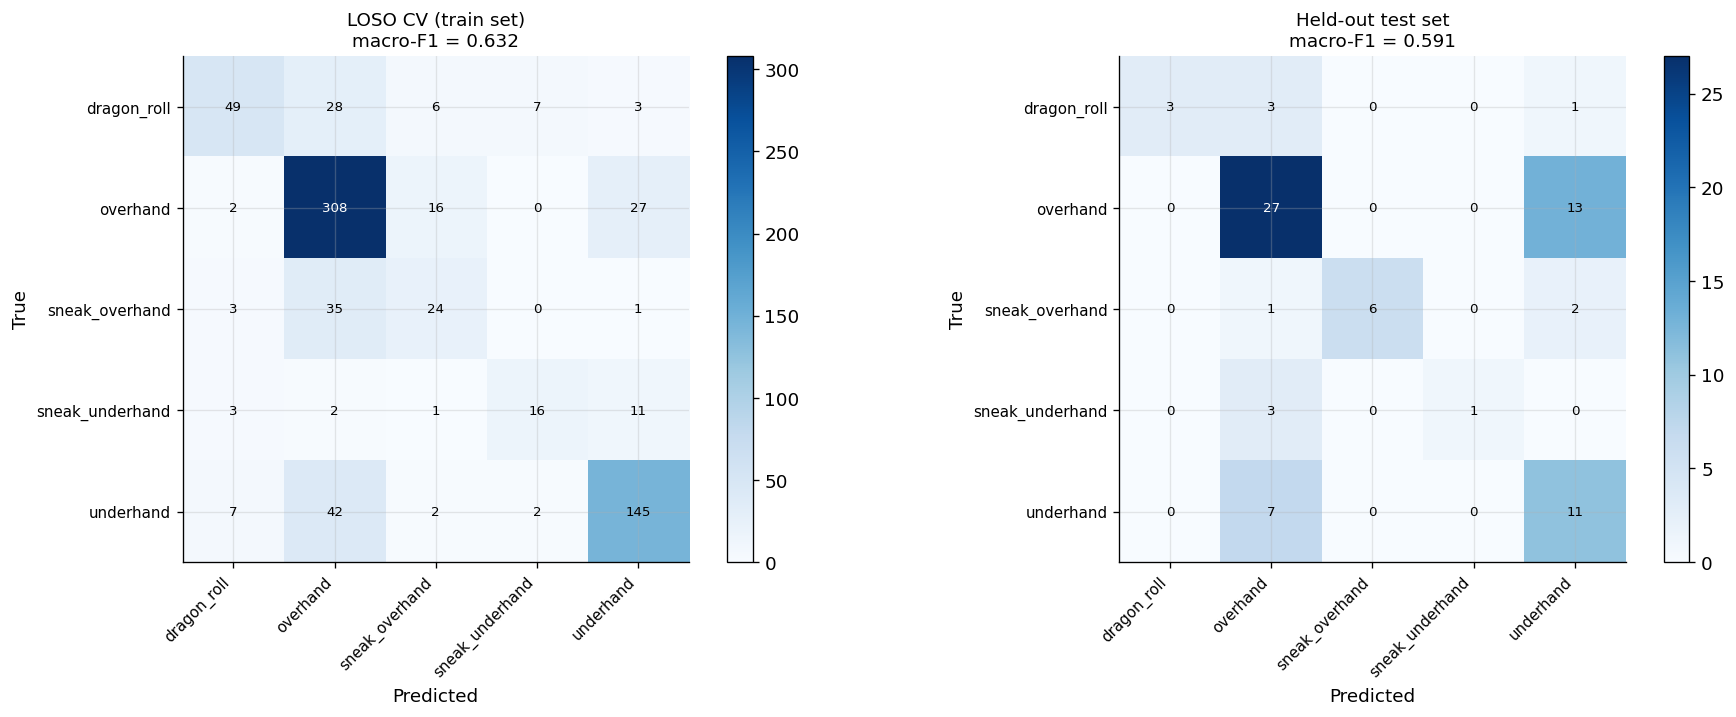

In [40]:
# ── Confusion matrices ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, res, title in zip(
    axes,
    [loso_results, test_results],
    ['LOSO CV (train set)', 'Held-out test set']
):
    if 'fine_cm' not in res:
        ax.set_title(f'{title} — no data'); continue
    cm = res['fine_cm']
    classes = res['fine_classes']
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(classes))); ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(classes, fontsize=9)
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()*0.5 else 'black', fontsize=8)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    f1 = res.get('fine_f1_macro', res.get('test_f1_macro', 0))
    ax.set_title(f'{title}\nmacro-F1 = {f1:.3f}', fontsize=11)
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig_confusion_matrices.png'), bbox_inches='tight')
plt.show()


### 8.2  LOSO vs test F1 comparison

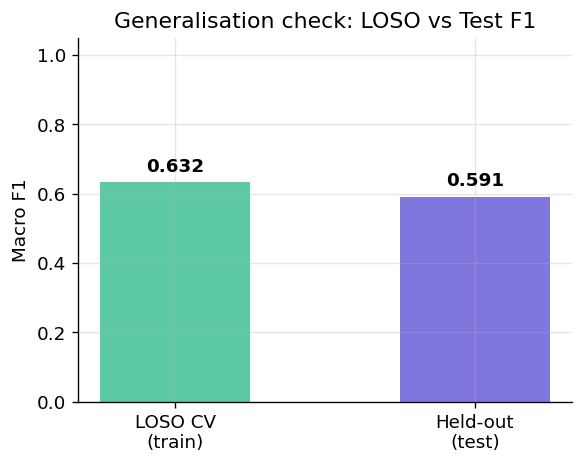

In [41]:
# ── LOSO vs Test F1 comparison bar chart ─────────────────────────────
loso_f1  = loso_results.get('fine_f1_macro', 0)
test_f1  = test_results.get('test_f1_macro', 0)

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['LOSO CV\n(train)', 'Held-out\n(test)'], [loso_f1, test_f1],
              color=['#5DCAA5', '#7F77DD'], width=0.5)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Macro F1')
ax.set_title('Generalisation check: LOSO vs Test F1')
for bar, val in zip(bars, [loso_f1, test_f1]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig_f1_comparison.png'), bbox_inches='tight')
plt.show()


### 8.3  Feature importance (tier-colored)

dom_axis_signed_mean_d0: 0.060349
dom_axis_signed_mean_d1: 0.053040
energy_y_d0: 0.042249
shape_pc_27: 0.038508
phase_yz_d0: 0.034429
mean_omega_d1: 0.033337
mean_omega_d0: 0.032823
energy_z_d0: 0.028692
energy_z_d1: 0.024546
energy_x_d1: 0.024209
phase_yz_d1: 0.023552
wind_wy_d0: 0.019516
energy_x_d0: 0.018286
shape_pc_33: 0.018232
acc_rms_d1: 0.015742
total_energy: 0.015247
phase_xz_d0: 0.014182
shape_pc_34: 0.013857
acc_rms_d0: 0.013265
omega_std_ratio: 0.012249


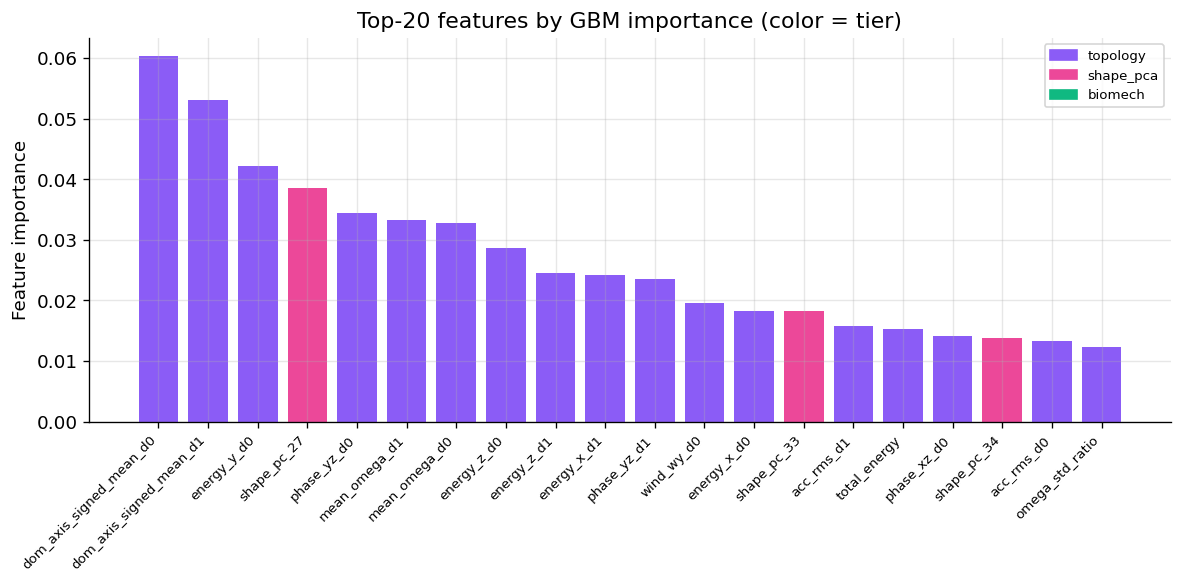

In [42]:
# ── Feature importance (tier-colored) ────────────────────────────────
TIER_COLORS = {
    'topology': '#8B5CF6',
    'shape_pca': '#EC4899',
    'biomech': '#10B981',
}
TIER_RANGES = {
    'topology': (0, N_BASE_FEAT),
    'shape_pca':(N_BASE_FEAT, 10**9),
}
def get_tier(name):
    if name.startswith(SHAPE_PCA_NAME_PREFIX):
        return 'shape_pca'
    idx = feat_names.index(name) if name in feat_names else -1
    for tier, (lo, hi) in TIER_RANGES.items():
        if lo <= idx < hi:
            return tier
    return 'other'

imp = MODEL_FINAL['clf'].feature_importances_
feat_names = MODEL_FINAL['feature_names']
order = np.argsort(imp)[::-1][:20]
top20 = [(feat_names[i], imp[i]) for i in order]
for name, val in top20:
    print(f"{name}: {val:.6f}")
colors = [TIER_COLORS.get(get_tier(feat_names[i]), '#aaa') for i in order]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(order)), imp[order], color=colors)
ax.set_xticks(range(len(order)))
ax.set_xticklabels([feat_names[i] for i in order], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Feature importance')
ax.set_title('Top-20 features by GBM importance (color = tier)')
from matplotlib.patches import Patch
patches = [Patch(color=c, label=t) for t, c in TIER_COLORS.items()]
ax.legend(handles=patches, loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig_feature_importance.png'), bbox_inches='tight')
plt.show()


---
## 9. Summary

In [43]:
# ── Pipeline summary ─────────────────────────────────────────────────
print('='*80)
print('PIPELINE SUMMARY')
print('='*80)
print(f'  Total sessions     : {len(ALL_SESSIONS)} entries '
      f'({sum(1 for e in ALL_SESSIONS if e[4] is None)} homogeneous, '
      f'{sum(1 for e in ALL_SESSIONS if e[4] is not None)} heterogeneous)')
print(f'  Train entries      : {len(TRAIN_SESSIONS)}')
print(f'  Test  entries      : {len(TEST_SESSIONS)}')
print(f'  LOSO  macro-F1     : {loso_results.get("fine_f1_macro",0):.3f}')
print(f'  Test  macro-F1     : {test_results.get("test_f1_macro",0):.3f}')
n_train_cycles = MODEL_FINAL["X_train"].shape[0]
print(f'  Training cycles    : {n_train_cycles}')
print(f'  Feature dim        : {MODEL_FINAL["X_train"].shape[1]}')
print(f'  Classes            : {list(MODEL_FINAL["label_encoder"].classes_)}')


PIPELINE SUMMARY
  Total sessions     : 66 entries (11 homogeneous, 55 heterogeneous)
  Train entries      : 56
  Test  entries      : 10
  LOSO  macro-F1     : 0.632
  Test  macro-F1     : 0.591
  Training cycles    : 2197
  Feature dim        : 149
  Classes            : [np.str_('dragon_roll'), np.str_('overhand'), np.str_('sneak_overhand'), np.str_('sneak_underhand'), np.str_('underhand')]


In [44]:
imp = MODEL_FINAL['clf'].feature_importances_
fnames = MODEL_FINAL['feature_names']
top20 = np.argsort(imp)[::-1][:20]
print("Top 20 features by GBM importance:")
for rank, idx in enumerate(top20):
    print(f"  {rank+1:>2d}. {fnames[idx]:<40s} {imp[idx]:.4f}")
print(f"\nTotal features: {len(fnames)}")
print(f"Features with importance > 0.01: {np.sum(imp > 0.01)}")
print(f"Features with importance < 0.001: {np.sum(imp < 0.001)}")

Top 20 features by GBM importance:
   1. dom_axis_signed_mean_d0                  0.0603
   2. dom_axis_signed_mean_d1                  0.0530
   3. energy_y_d0                              0.0422
   4. shape_pc_27                              0.0385
   5. phase_yz_d0                              0.0344
   6. mean_omega_d1                            0.0333
   7. mean_omega_d0                            0.0328
   8. energy_z_d0                              0.0287
   9. energy_z_d1                              0.0245
  10. energy_x_d1                              0.0242
  11. phase_yz_d1                              0.0236
  12. wind_wy_d0                               0.0195
  13. energy_x_d0                              0.0183
  14. shape_pc_33                              0.0182
  15. acc_rms_d1                               0.0157
  16. total_energy                             0.0152
  17. phase_xz_d0                              0.0142
  18. shape_pc_34                              

In [45]:
# DIAGNOSTIC: full feature kill list
imp = MODEL_FINAL['clf'].feature_importances_
fnames = MODEL_FINAL['feature_names']
print(f"Total features: {len(fnames)}")
print(f"Features with importance > 0.01: {sum(imp > 0.01)}")
print(f"Features with importance 0.001-0.01: {sum((imp >= 0.001) & (imp < 0.01))}")
print(f"Features with importance < 0.001: {sum(imp < 0.001)}")
print(f"\n--- KEEP (importance >= 0.005) ---")
for i in np.argsort(imp)[::-1]:
    if imp[i] >= 0.005:
        print(f"  {fnames[i]:<45s} {imp[i]:.4f}")
print(f"\n--- MAYBE (0.001 <= importance < 0.005) ---")
for i in np.argsort(imp)[::-1]:
    if 0.001 <= imp[i] < 0.005:
        print(f"  {fnames[i]:<45s} {imp[i]:.4f}")
print(f"\n--- DELETE (importance < 0.001) ---")
for i in np.argsort(imp)[::-1]:
    if imp[i] < 0.001:
        print(f"  {fnames[i]:<45s} {imp[i]:.6f}")

Total features: 149
Features with importance > 0.01: 28
Features with importance 0.001-0.01: 100
Features with importance < 0.001: 21

--- KEEP (importance >= 0.005) ---
  dom_axis_signed_mean_d0                       0.0603
  dom_axis_signed_mean_d1                       0.0530
  energy_y_d0                                   0.0422
  shape_pc_27                                   0.0385
  phase_yz_d0                                   0.0344
  mean_omega_d1                                 0.0333
  mean_omega_d0                                 0.0328
  energy_z_d0                                   0.0287
  energy_z_d1                                   0.0245
  energy_x_d1                                   0.0242
  phase_yz_d1                                   0.0236
  wind_wy_d0                                    0.0195
  energy_x_d0                                   0.0183
  shape_pc_33                                   0.0182
  acc_rms_d1                                    0.0157
  tot